# Home Credit Default Risk — Modeling Pipeline

## Pipeline Overview
```
Step 1: Load preprocessed datasets (4 variants)
         ├── traditional_pca
         ├── traditional_no_pca
         ├── combined_pca
         └── combined_no_pca
Step 2: Baseline Models (LR, LightGBM, XGBoost, RandomForest)
         └── Ensemble downsampling: majority split into K folds,
             each fold trains all minority + 1/K majority → average probas
Step 3: Evaluation Tables + Plots per dataset variant
         ├── Metrics table (Recall, Precision, F1, Accuracy, AUC)
         ├── AUC Bar Chart across all variants
         ├── ROC Curves
         ├── Precision-Recall Curves
         ├── Confusion Matrices
         ├── Feature Importances (all 4 models: LR coef + tree gain)
         ├── Lift Chart + KS Plot
         └── Cross-Dataset AUC Heatmap
Step 4: Hyperparameter Tuning (RandomizedSearchCV, n_iter=5)
         ├── Best params log
         ├── Baseline vs Tuned AUC comparison
         └── Tuned ROC + AUC heatmap
Step 5: Final evaluation on test set with best tuned models
         ├── Test metrics tables
         ├── Test ROC Curves
         ├── Final AUC heatmap
         └── Overall best model summary
Step 6: SHAP Analysis — all 4 models on best dataset
         ├── Beeswarm summary plots
         ├── Bar importance plots
         ├── SHAP vs Native importance comparison
         ├── Dependence plots (top 4 features per model)
         ├── Waterfall plots (top 3 high-risk samples per model)
         ├── SHAP heatmaps
         └── SHAP feature importance tables
```

## 1. Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')
shap.initjs()

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    recall_score, precision_score, f1_score, accuracy_score, roc_auc_score,
    roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils import shuffle
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import pipelines.project_config as cfg

sns.set_style('whitegrid')
SEED = 42
DO_HYPERTUNING      = False
N_ENSEMBLE_FOLDS    = 3
pd.set_option('display.max_columns', 80)

print('Libraries loaded.')
print(f'Hyperparameter tuning  : {"ENABLED" if DO_HYPERTUNING else "DISABLED"}')
print(f'Ensemble folds (K)     : {N_ENSEMBLE_FOLDS}')
print('Downsampling strategy  : majority split into K folds; each run uses all minority + 1/K majority; probas averaged.')

/home/braum/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded.
Hyperparameter tuning  : DISABLED
Ensemble folds (K)     : 3
Downsampling strategy  : majority split into K folds; each run uses all minority + 1/K majority; probas averaged.


## 2. Load Datasets

In [2]:
def load_split(directory):
    train = pd.read_csv(f"{directory}/{cfg.PREPROCESSED_FILENAMES['train']}")
    val   = pd.read_csv(f"{directory}/{cfg.PREPROCESSED_FILENAMES['validation']}")
    test  = pd.read_csv(f"{directory}/{cfg.PREPROCESSED_FILENAMES['test']}")
    return train, val, test

def xy(df):
    return df.drop(columns=[cfg.TARGET_COL]), df[cfg.TARGET_COL]

datasets = {
    'traditional_pca':    load_split(cfg.PREPROCESSED_TRADITIONAL_PCA_DIR),
    'traditional_no_pca': load_split(cfg.PREPROCESSED_TRADITIONAL_NO_PCA_DIR),
    'combined_pca':       load_split(cfg.PREPROCESSED_COMBINED_PCA_DIR),
    'combined_no_pca':    load_split(cfg.PREPROCESSED_COMBINED_NO_PCA_DIR),
}

print('Dataset shapes:')
for name, (tr, va, te) in datasets.items():
    print(f'  {name:25s}  train={tr.shape}  val={va.shape}  test={te.shape}')

Dataset shapes:
  traditional_pca            train=(215257, 52)  val=(46127, 52)  test=(46127, 52)
  traditional_no_pca         train=(215257, 65)  val=(46127, 65)  test=(46127, 65)
  combined_pca               train=(215257, 86)  val=(46127, 86)  test=(46127, 86)
  combined_no_pca            train=(215257, 120)  val=(46127, 120)  test=(46127, 120)


In [3]:
print('\nChecking for non-numeric columns:')
for dataset_name, (train_df, val_df, test_df) in datasets.items():
    X_train, y_train = xy(train_df)
    object_cols = X_train.select_dtypes(include='object').columns.tolist()
    if object_cols:
        print(f'\n{dataset_name}:')
        print(f'  Found {len(object_cols)} object columns: {object_cols[:5]}...')
    else:
        print(f'\n{dataset_name}: All columns numeric ✓')


Checking for non-numeric columns:

traditional_pca: All columns numeric ✓

traditional_no_pca: All columns numeric ✓

combined_pca: All columns numeric ✓

combined_no_pca: All columns numeric ✓


## 3. Helper Functions

In [4]:
def make_ensemble_splits(X, y, K=N_ENSEMBLE_FOLDS, seed=SEED):
    """
    Split majority class into K non-overlapping chunks.
    Each fold contains ALL minority samples + 1/K of the majority samples.
    Returns a list of K (X_fold, y_fold) tuples.
    """
    rng = np.random.default_rng(seed)

    minority_mask = (y == 1)
    X_min = X[minority_mask]
    y_min = y[minority_mask]
    X_maj = X[~minority_mask]
    y_maj = y[~minority_mask]

    maj_idx = rng.permutation(len(X_maj))
    chunks  = np.array_split(maj_idx, K)

    folds = []
    for chunk in chunks:
        X_fold = pd.concat([X_min, X_maj.iloc[chunk]], ignore_index=True)
        y_fold = pd.concat([y_min, y_maj.iloc[chunk]], ignore_index=True)
        X_fold, y_fold = shuffle(X_fold, y_fold, random_state=int(rng.integers(0, 9999)))
        folds.append((X_fold, y_fold))

    minority_pct = len(y_min) / (len(y_min) + len(maj_idx) // K) * 100
    print(f'  Ensemble folds: {K}  |  minority samples: {len(y_min)}  '
          f'|  majority per fold: ~{len(maj_idx)//K}  '
          f'|  minority % per fold: ~{minority_pct:.1f}%')
    return folds


def train_ensemble(base_model_fn, X, y, K=N_ENSEMBLE_FOLDS, seed=SEED):
    """
    Train K models, one per ensemble fold.
    base_model_fn() must return a fresh, unfitted model.
    Returns a list of K fitted models.
    """
    folds  = make_ensemble_splits(X, y, K=K, seed=seed)
    models = []
    for i, (X_fold, y_fold) in enumerate(folds):
        m = base_model_fn()
        m.fit(X_fold, y_fold)
        models.append(m)
    return models


def predict_proba_ensemble(models, X):
    """Average predicted probabilities across all K models."""
    probas = np.stack([m.predict_proba(X)[:, 1] for m in models], axis=0)
    return probas.mean(axis=0)


def evaluate_ensemble(models, X, y, threshold=0.5):
    proba = predict_proba_ensemble(models, X)
    preds = (proba >= threshold).astype(int)
    return {
        'Recall':    recall_score(y, preds, zero_division=0),
        'Precision': precision_score(y, preds, zero_division=0),
        'F1':        f1_score(y, preds, zero_division=0),
        'Accuracy':  accuracy_score(y, preds),
        'AUC':       roc_auc_score(y, proba),
    }


def make_model_factory(scale_pos_weight=1.0):
    """Returns a dict of {model_name: callable} where each call gives a fresh model."""
    return {
        'LogisticRegression': lambda: LogisticRegression(
            max_iter=3000, random_state=SEED, class_weight='balanced',
            solver='saga', penalty='l2', C=0.1
        ),
        'LightGBM': lambda: LGBMClassifier(
            n_estimators=1000, learning_rate=0.05, num_leaves=64,
            max_depth=8, class_weight='balanced', subsample=0.8,
            colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1,
            random_state=SEED, verbose=-1, importance_type='gain'
        ),
        'XGBoost': lambda: XGBClassifier(
            n_estimators=1000, learning_rate=0.05, max_depth=8,
            min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight, tree_method='hist',
            random_state=SEED, eval_metric='logloss'
        ),
        'RandomForest': lambda: RandomForestClassifier(
            n_estimators=300, max_depth=15, min_samples_leaf=20,
            max_features='sqrt', class_weight='balanced_subsample',
            random_state=SEED
        ),
    }

MODEL_COLORS = {
    'LogisticRegression': '#1976d2',
    'LightGBM':           '#4caf50',
    'XGBoost':            '#ff9800',
    'RandomForest':       '#9c27b0',
}

## 4. Baseline Models — Train & Evaluate

> **Ensemble downsampling**: the majority class is split into **K = `N_ENSEMBLE_FOLDS`** non-overlapping chunks. For each chunk we train a fresh model on *all* minority samples + that 1/K slice of the majority. Final predicted probabilities are the mean across all K models.

In [5]:
baseline_fitted  = {}
baseline_results = {}
baseline_probas  = {}

for dataset_name, (train_df, val_df, test_df) in datasets.items():
    print(f'\n[{dataset_name}]')
    X_train, y_train = xy(train_df)
    X_val,   y_val   = xy(val_df)

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    factories = make_model_factory(scale_pos_weight=scale_pos_weight)

    rows   = {}
    probas = {}
    fitted = {}

    for model_name, model_fn in factories.items():
        print(f'  Training {model_name} ({N_ENSEMBLE_FOLDS} folds)...')
        ensemble = train_ensemble(model_fn, X_train, y_train, K=N_ENSEMBLE_FOLDS)
        fitted[model_name]  = ensemble
        rows[model_name]    = evaluate_ensemble(ensemble, X_val, y_val)
        probas[model_name]  = predict_proba_ensemble(ensemble, X_val)
        print(f'    → AUC={rows[model_name]["AUC"]:.4f}  Recall={rows[model_name]["Recall"]:.4f}')

    baseline_fitted[dataset_name]  = fitted
    baseline_results[dataset_name] = rows
    baseline_probas[dataset_name]  = (probas, y_val)

print('\nBaseline training complete.')


[traditional_pca]
  Training LogisticRegression (3 folds)...


  Ensemble folds: 3  |  minority samples: 17412  |  majority per fold: ~65948  |  minority % per fold: ~20.9%
    → AUC=0.6324  Recall=0.5257
  Training LightGBM (3 folds)...
  Ensemble folds: 3  |  minority samples: 17412  |  majority per fold: ~65948  |  minority % per fold: ~20.9%
    → AUC=0.6415  Recall=0.3460
  Training XGBoost (3 folds)...
  Ensemble folds: 3  |  minority samples: 17412  |  majority per fold: ~65948  |  minority % per fold: ~20.9%
    → AUC=0.6273  Recall=0.3985
  Training RandomForest (3 folds)...
  Ensemble folds: 3  |  minority samples: 17412  |  majority per fold: ~65948  |  minority % per fold: ~20.9%
    → AUC=0.6741  Recall=0.4151

[traditional_no_pca]
  Training LogisticRegression (3 folds)...
  Ensemble folds: 3  |  minority samples: 17412  |  majority per fold: ~65948  |  minority % per fold: ~20.9%
    → AUC=0.7466  Recall=0.6738
  Training LightGBM (3 folds)...
  Ensemble folds: 3  |  minority samples: 17412  |  majority per fold: ~65948  |  minority

### 4.1 Baseline Metrics Tables

In [6]:
for dataset_name, rows in baseline_results.items():
    print(f'\n=== {dataset_name} ===')
    df_res = pd.DataFrame(rows).T[['Recall', 'Precision', 'F1', 'Accuracy', 'AUC']]
    display(df_res.style.format('{:.4f}').background_gradient(cmap='Blues', axis=0).set_caption(dataset_name))


=== traditional_pca ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.5257,0.1210,0.1967,0.6574,0.6324
LightGBM,0.3460,0.1470,0.2063,0.7877,0.6415
XGBoost,0.3985,0.1327,0.1991,0.7443,0.6273
RandomForest,0.4151,0.1577,0.2285,0.7765,0.6741



=== traditional_no_pca ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.6738,0.1579,0.2558,0.6873,0.7466
LightGBM,0.5711,0.1989,0.2950,0.7823,0.7664
XGBoost,0.6939,0.1629,0.2638,0.6912,0.7564
RandomForest,0.5871,0.1889,0.2859,0.7661,0.7572



=== combined_pca ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.5376,0.1247,0.2024,0.6621,0.6532
LightGBM,0.1731,0.1602,0.1664,0.8616,0.6367
XGBoost,0.1851,0.1421,0.1608,0.8459,0.6156
RandomForest,0.2066,0.1640,0.1828,0.8527,0.6495



=== combined_no_pca ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.6975,0.1671,0.2696,0.6986,0.7668
LightGBM,0.5708,0.2213,0.3189,0.8056,0.7846
XGBoost,0.6540,0.1845,0.2879,0.7419,0.7739
RandomForest,0.5594,0.2051,0.3002,0.7919,0.7704


### 4.2 Baseline AUC Bar Chart — All Dataset Variants

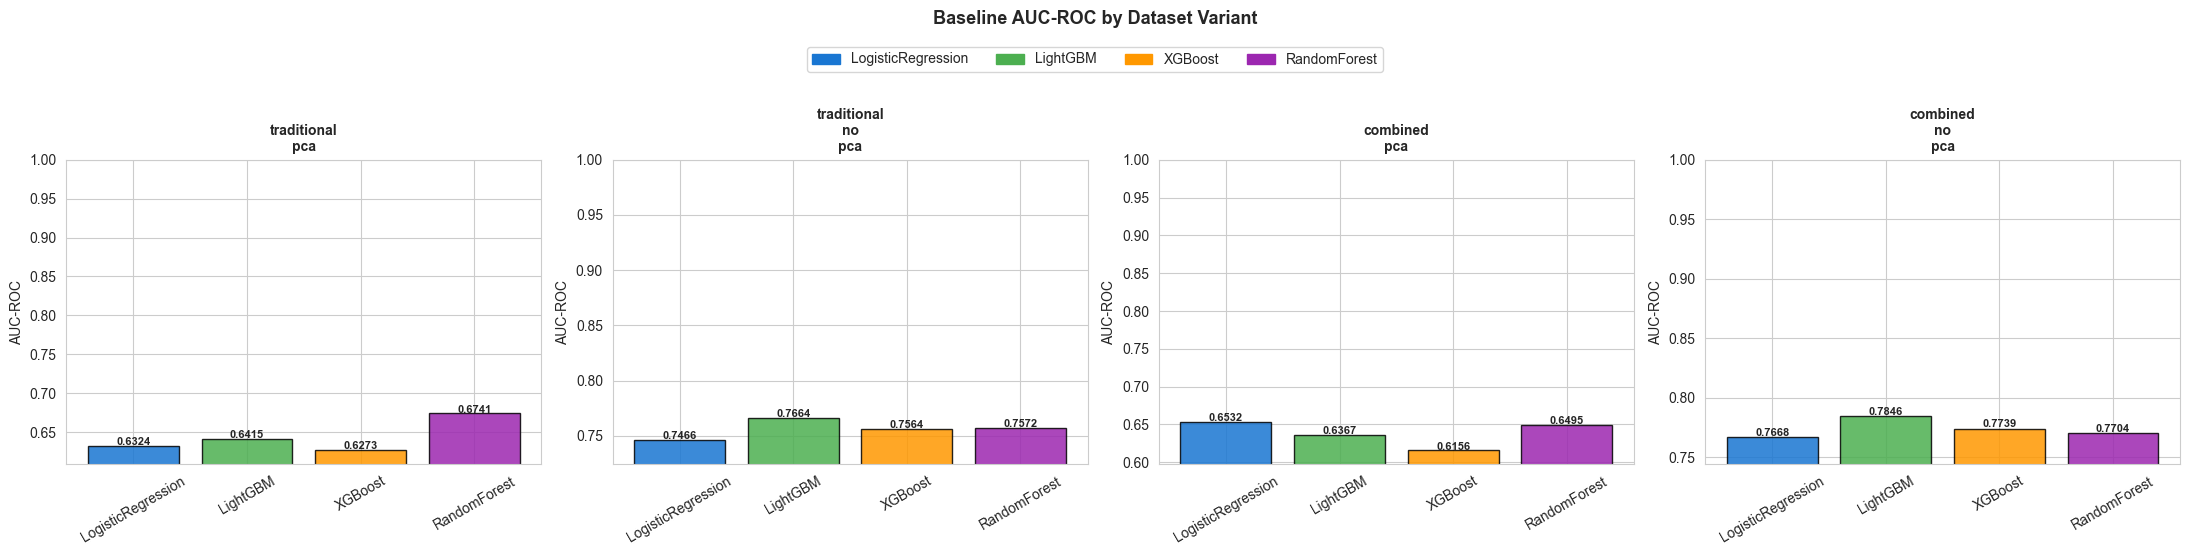

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=False)

for ax, (dataset_name, rows) in zip(axes, baseline_results.items()):
    model_names = list(rows.keys())
    aucs = [rows[m]['AUC'] for m in model_names]
    colors = [MODEL_COLORS[m] for m in model_names]
    bars = ax.bar(model_names, aucs, color=colors, edgecolor='black', alpha=0.85)
    ax.set_ylim(min(aucs) * 0.97, 1.0)
    ax.set_title(dataset_name.replace('_', '\n'), fontweight='bold', fontsize=10)
    ax.set_ylabel('AUC-ROC')
    ax.tick_params(axis='x', rotation=30)
    for bar, v in zip(bars, aucs):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.001, f'{v:.4f}',
                ha='center', fontsize=8, fontweight='bold')

legend_patches = [mpatches.Patch(color=c, label=m) for m, c in MODEL_COLORS.items()]
fig.legend(handles=legend_patches, loc='upper center', ncol=4, fontsize=10, bbox_to_anchor=(0.5, 1.04))
plt.suptitle('Baseline AUC-ROC by Dataset Variant', fontweight='bold', fontsize=13, y=1.10)
plt.tight_layout()
plt.show()

### 4.3 Cross-Dataset AUC Heatmap

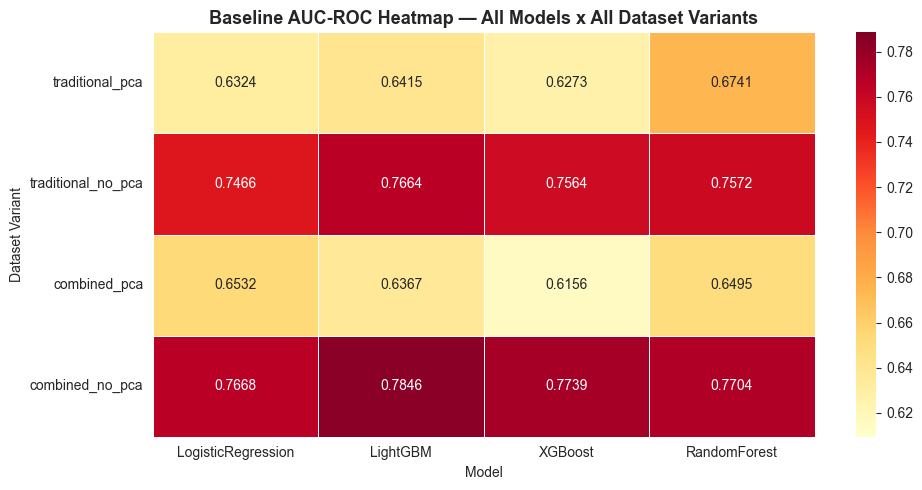

In [8]:
auc_matrix = pd.DataFrame(
    {ds: {m: baseline_results[ds][m]['AUC'] for m in baseline_results[ds]}
     for ds in baseline_results}
).T

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    auc_matrix.astype(float), annot=True, fmt='.4f',
    cmap='YlOrRd', ax=ax, linewidths=0.5,
    vmin=auc_matrix.values.min() * 0.99,
    vmax=auc_matrix.values.max() * 1.005
)
ax.set_title('Baseline AUC-ROC Heatmap — All Models x All Dataset Variants', fontweight='bold', fontsize=13)
ax.set_xlabel('Model')
ax.set_ylabel('Dataset Variant')
plt.tight_layout()
plt.show()

### 4.4 ROC Curves — All Datasets

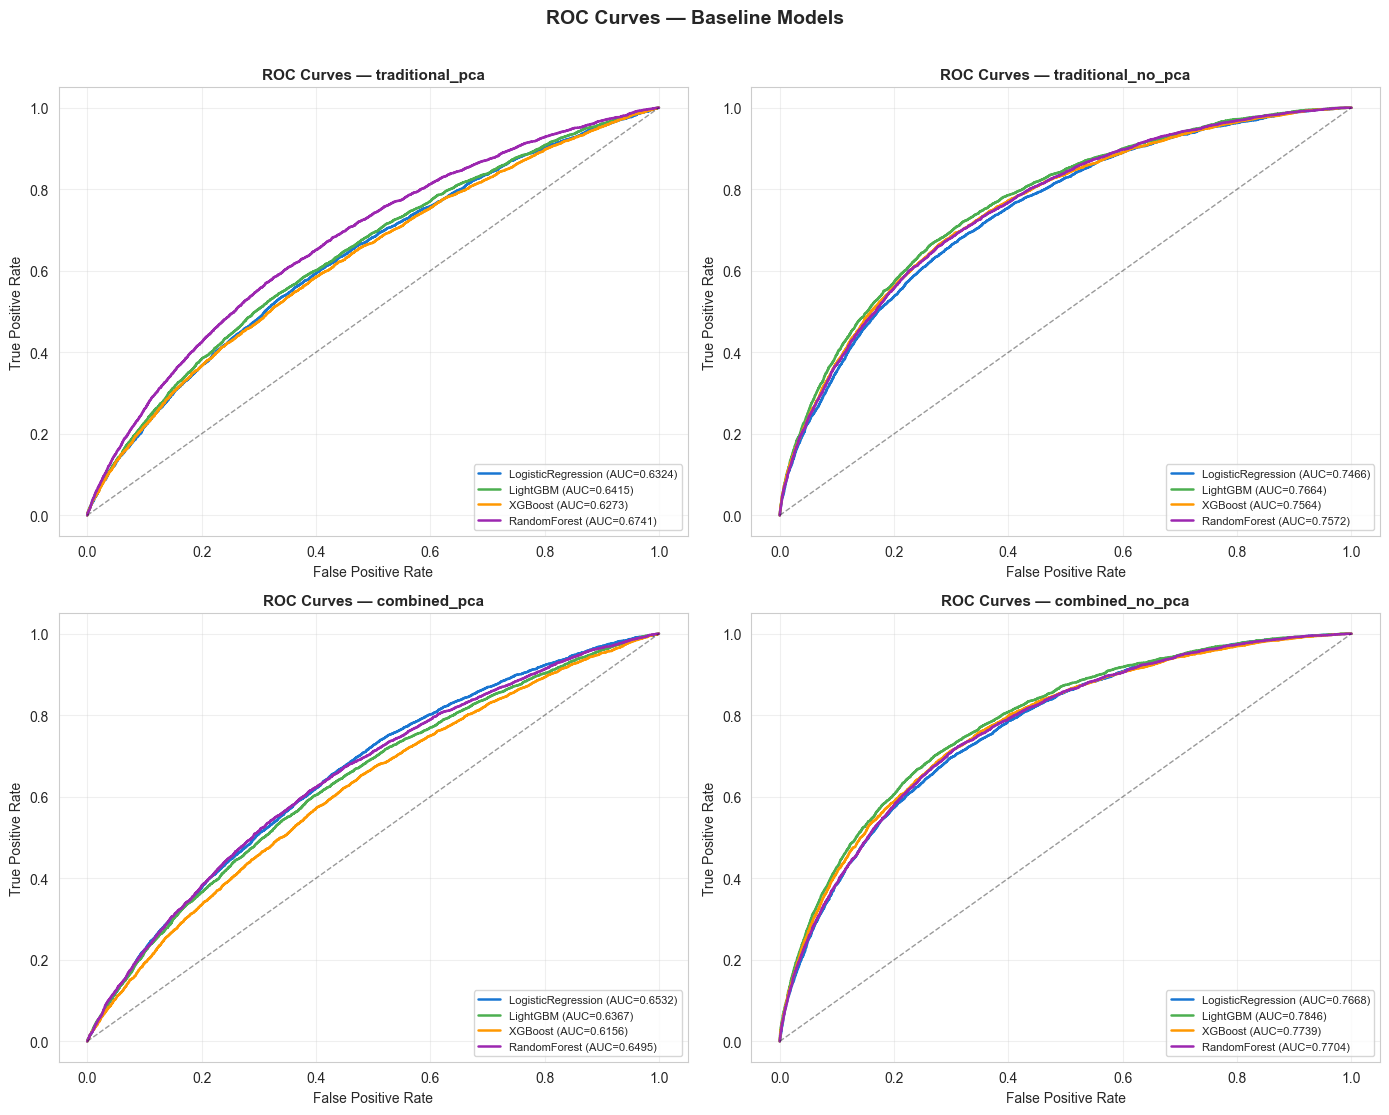

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for ax, (dataset_name, (probas, y_val)) in zip(axes.flatten(), baseline_probas.items()):
    for model_name, proba in probas.items():
        fpr, tpr, _ = roc_curve(y_val, proba)
        auc = roc_auc_score(y_val, proba)
        ax.plot(fpr, tpr, color=MODEL_COLORS[model_name], linewidth=1.8,
                label=f'{model_name} (AUC={auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves — {dataset_name}', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)

plt.suptitle('ROC Curves — Baseline Models', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 4.5 Precision-Recall Curves — All Datasets

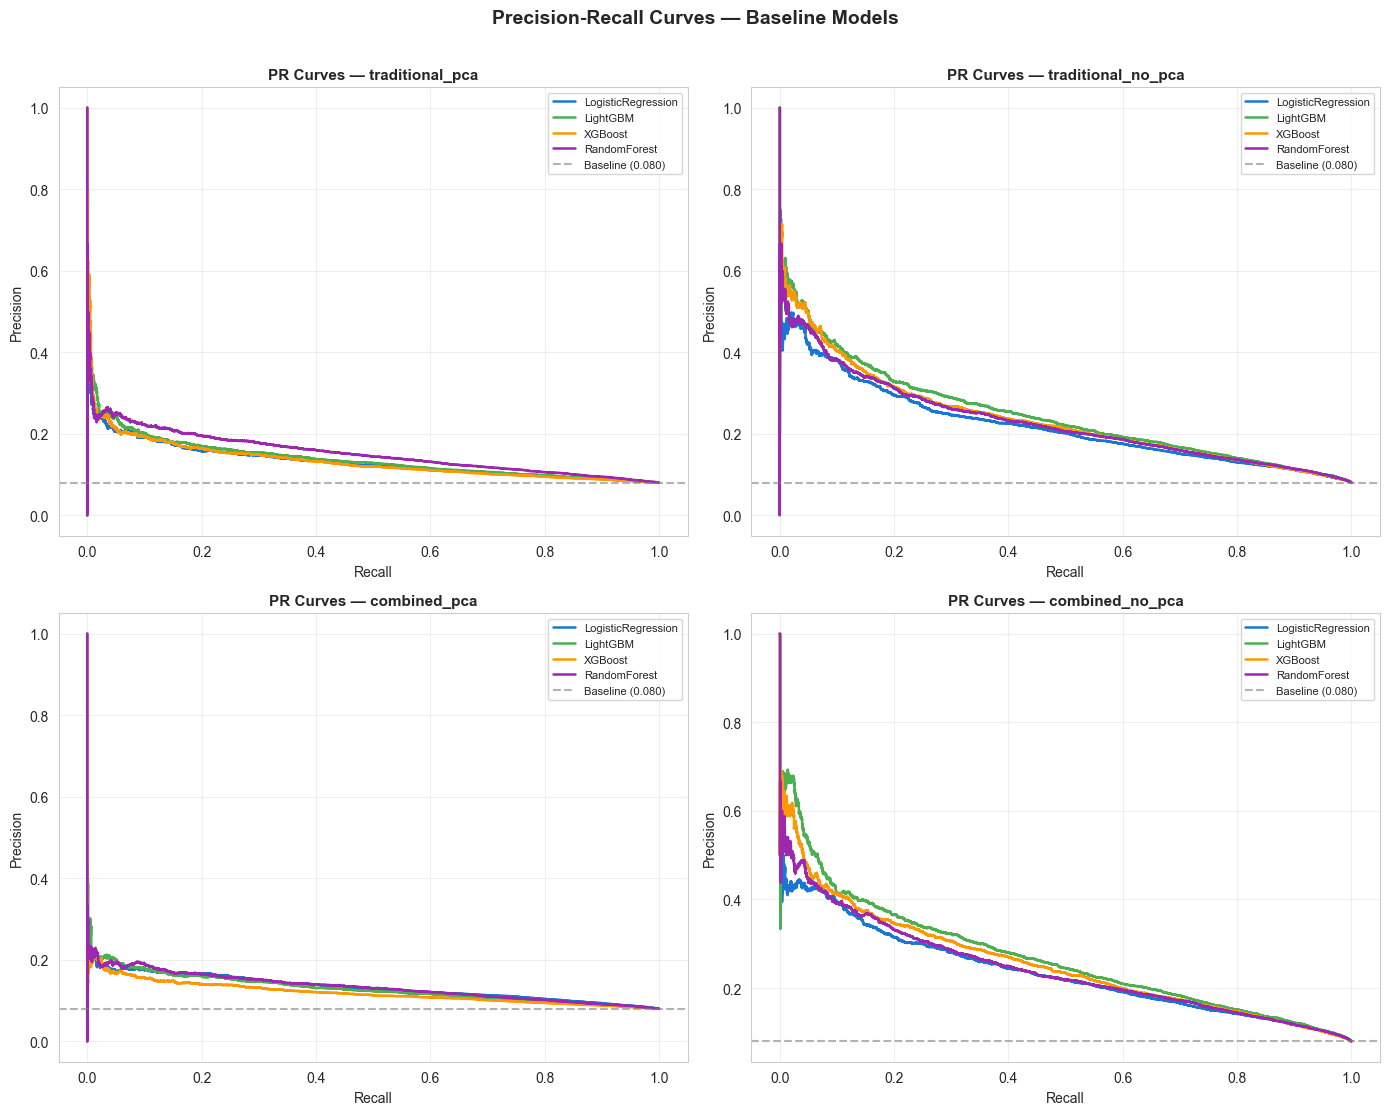

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for ax, (dataset_name, (probas, y_val)) in zip(axes.flatten(), baseline_probas.items()):
    baseline_rate = y_val.mean()
    for model_name, proba in probas.items():
        prec, rec, _ = precision_recall_curve(y_val, proba)
        ax.plot(rec, prec, color=MODEL_COLORS[model_name], linewidth=1.8, label=model_name)
    ax.axhline(y=baseline_rate, color='grey', linestyle='--', alpha=0.6,
               label=f'Baseline ({baseline_rate:.3f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'PR Curves — {dataset_name}', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Precision-Recall Curves — Baseline Models', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 4.6 Confusion Matrices — Best Performing Dataset

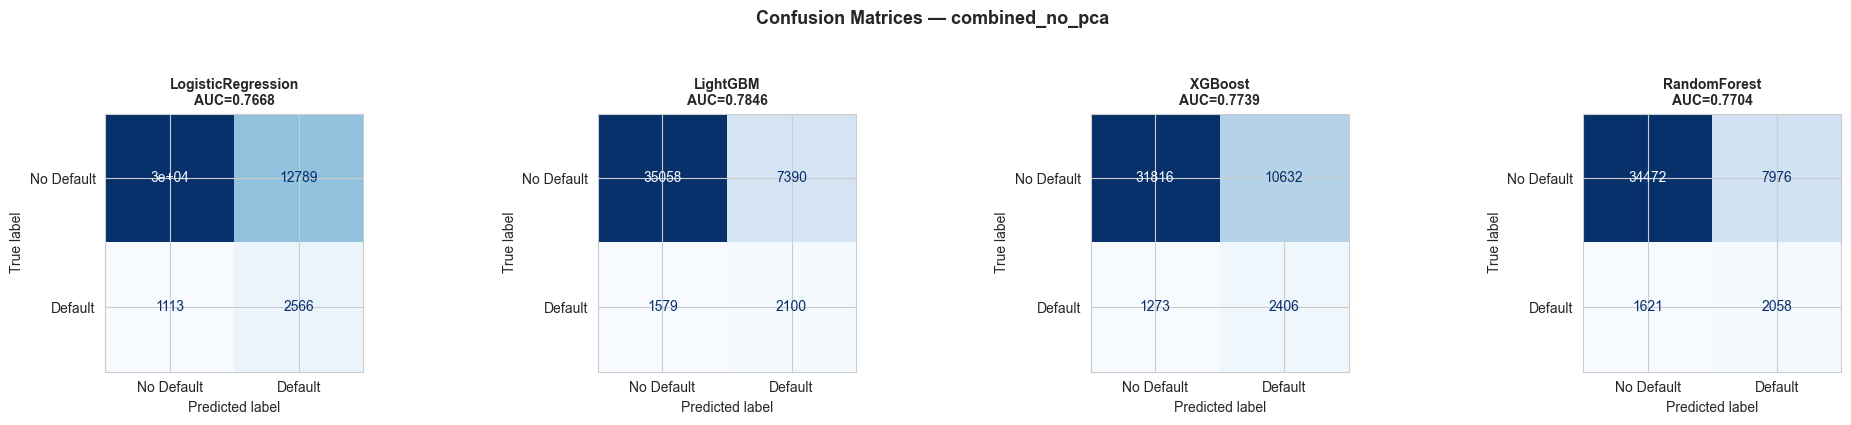

In [11]:
best_dataset = max(
    baseline_results,
    key=lambda d: max(v['AUC'] for v in baseline_results[d].values())
)
_, val_df_best, _ = datasets[best_dataset]
X_val_best, y_val_best = xy(val_df_best)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (model_name, ensemble) in zip(axes, baseline_fitted[best_dataset].items()):
    proba = predict_proba_ensemble(ensemble, X_val_best)
    preds = (proba >= 0.5).astype(int)
    cm = confusion_matrix(y_val_best, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    auc = baseline_results[best_dataset][model_name]['AUC']
    ax.set_title(f'{model_name}\nAUC={auc:.4f}', fontweight='bold', fontsize=10)

plt.suptitle(f'Confusion Matrices — {best_dataset}', fontweight='bold', fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

### 4.7 Feature Importances — All Models (Best Dataset)

> Logistic Regression uses the average absolute coefficient across ensemble folds as the importance signal (shown unsigned; bar colour encodes sign: blue = positive / increases default risk, red = negative).

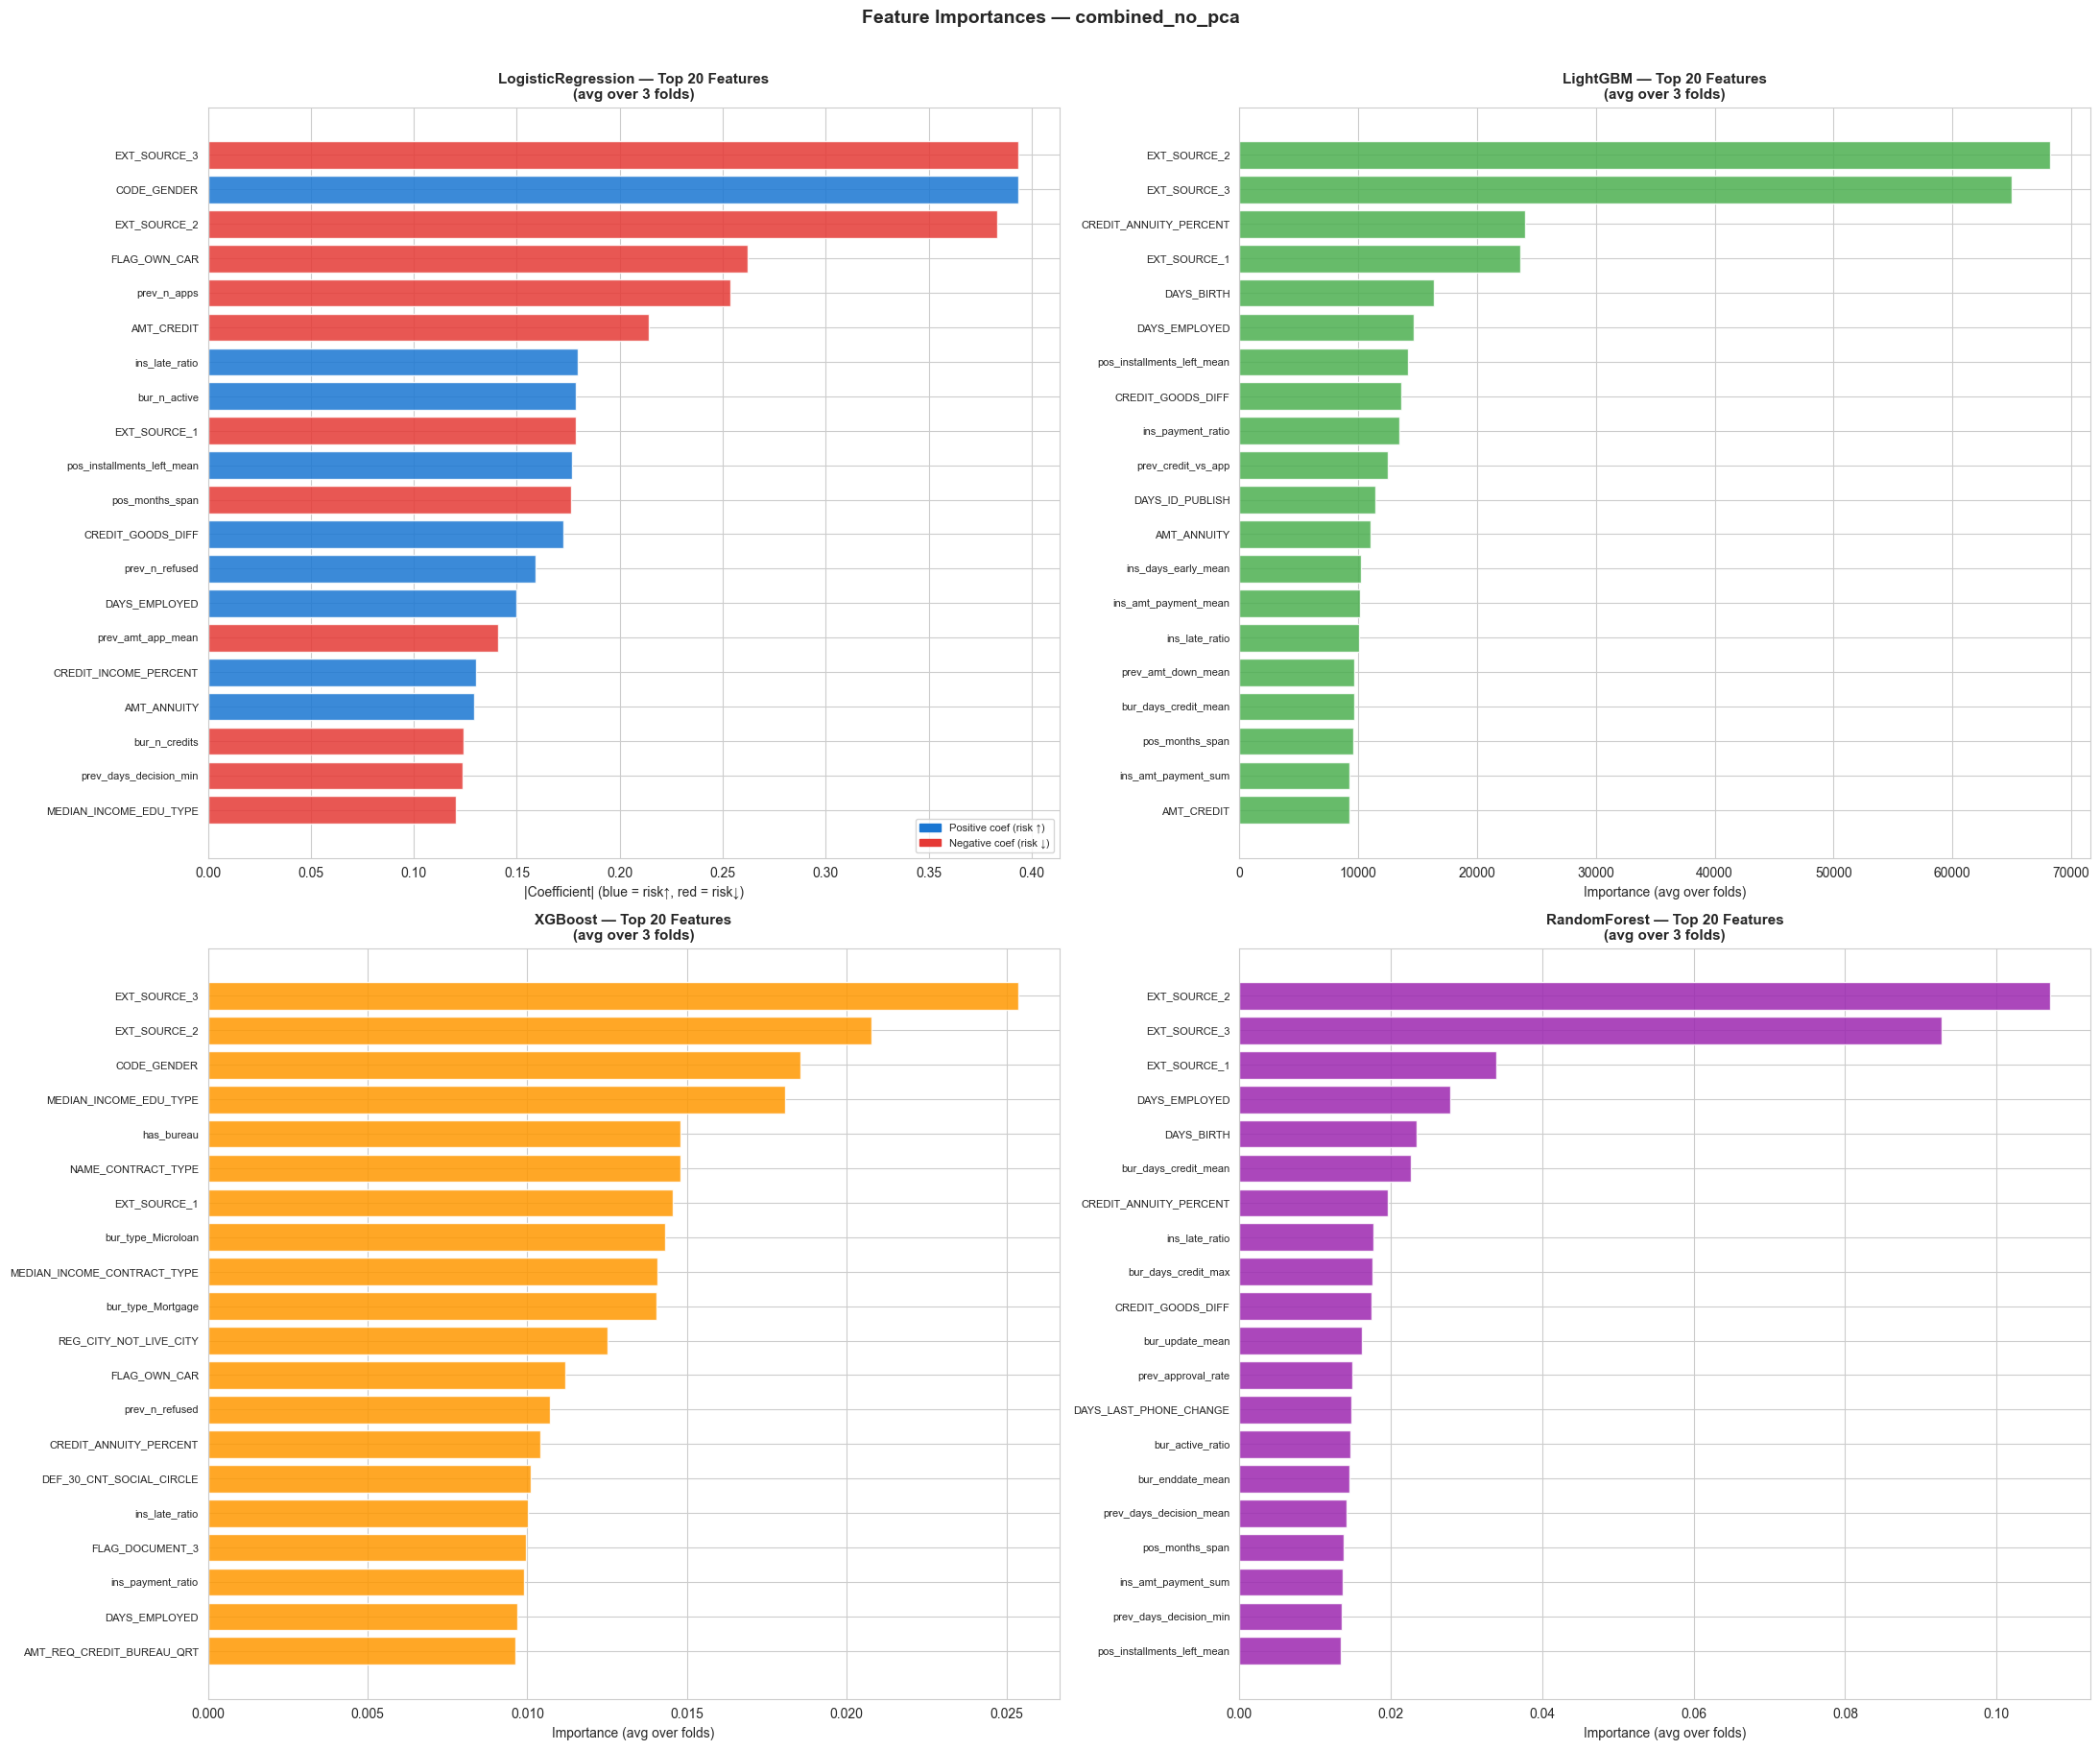

In [12]:
train_df_best, _, _ = datasets[best_dataset]
X_train_best, _ = xy(train_df_best)
feature_names = X_train_best.columns.tolist()

fig, axes = plt.subplots(2, 2, figsize=(22, 18))

for ax, model_name in zip(axes.flatten(), ['LogisticRegression', 'LightGBM', 'XGBoost', 'RandomForest']):
    ensemble = baseline_fitted[best_dataset][model_name]

    if model_name == 'LogisticRegression':
        avg_coef = np.mean([m.coef_[0] for m in ensemble], axis=0)
        importances = pd.Series(avg_coef, index=feature_names)
        top = importances.abs().nlargest(20)
        top_vals = importances.reindex(top.index).sort_values(key=abs)
        colors = [MODEL_COLORS[model_name] if v > 0 else '#e53935' for v in top_vals.values]
        ax.barh(range(len(top_vals)), top_vals.abs().values, color=colors, edgecolor='white', alpha=0.85)
        ax.set_xlabel('|Coefficient| (blue = risk↑, red = risk↓)')
        blue_patch = mpatches.Patch(color=MODEL_COLORS[model_name], label='Positive coef (risk ↑)')
        red_patch  = mpatches.Patch(color='#e53935',                 label='Negative coef (risk ↓)')
        ax.legend(handles=[blue_patch, red_patch], fontsize=8, loc='lower right')
    else:
        avg_importances = np.mean([m.feature_importances_ for m in ensemble], axis=0)
        importances = pd.Series(avg_importances, index=feature_names)
        top_vals = importances.nlargest(20).sort_values()
        ax.barh(range(len(top_vals)), top_vals.values,
                color=MODEL_COLORS[model_name], edgecolor='white', alpha=0.85)
        ax.set_xlabel('Importance (avg over folds)')

    ax.set_yticks(range(len(top_vals)))
    ax.set_yticklabels([n[:40] for n in top_vals.index], fontsize=8)
    ax.set_title(f'{model_name} — Top 20 Features\n(avg over {N_ENSEMBLE_FOLDS} folds)', fontweight='bold', fontsize=11)

plt.suptitle(f'Feature Importances — {best_dataset}', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 4.8 Lift Chart + KS Plot — Best Baseline Model

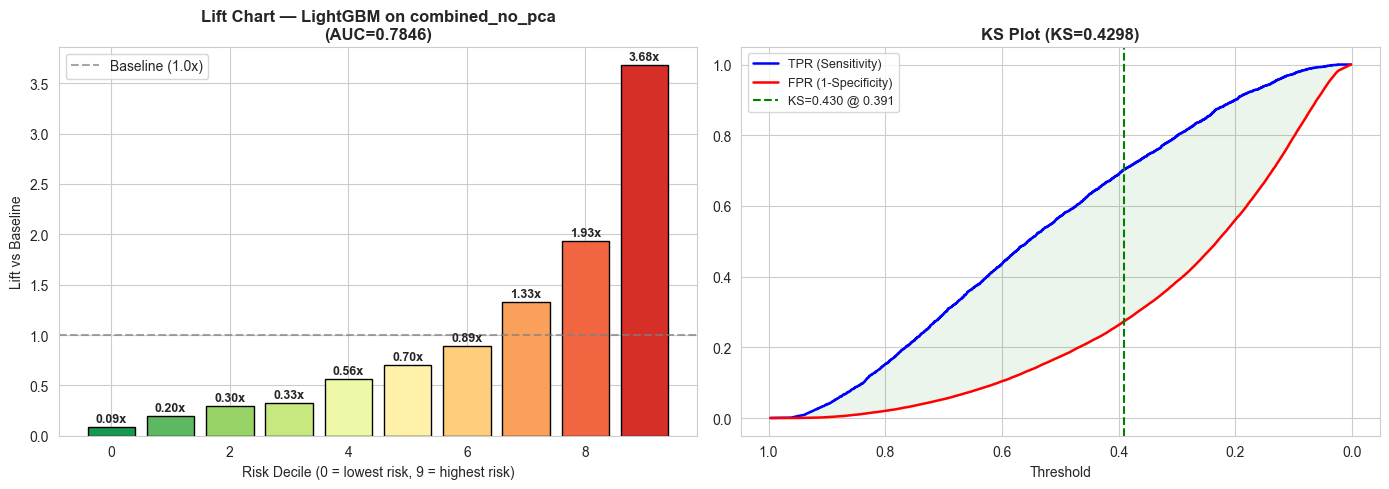

KS Statistic: 0.4298  (KS > 0.3 = production-ready scorecard)


In [13]:
best_model_name = max(
    baseline_results[best_dataset],
    key=lambda m: baseline_results[best_dataset][m]['AUC']
)
best_ensemble = baseline_fitted[best_dataset][best_model_name]
best_probas_dict, y_val_best = baseline_probas[best_dataset]
y_proba_best = best_probas_dict[best_model_name]

pred_df = pd.DataFrame({'pred': y_proba_best, 'actual': y_val_best.values})
pred_df['decile'] = pd.qcut(pred_df['pred'], q=10, labels=False, duplicates='drop')
lift = pred_df.groupby('decile')['actual'].mean() / y_val_best.mean()

fpr_k, tpr_k, thresholds_k = roc_curve(y_val_best, y_proba_best)
ks_stat = max(tpr_k - fpr_k)
ks_threshold = thresholds_k[np.argmax(tpr_k - fpr_k)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(
    range(len(lift)), lift.values,
    color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(lift))), edgecolor='black'
)
axes[0].axhline(1.0, color='grey', linestyle='--', alpha=0.7, label='Baseline (1.0x)')
for i, v in enumerate(lift.values):
    axes[0].text(i, v + 0.05, f'{v:.2f}x', ha='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Risk Decile (0 = lowest risk, 9 = highest risk)')
axes[0].set_ylabel('Lift vs Baseline')
axes[0].set_title(
    f'Lift Chart — {best_model_name} on {best_dataset}\n(AUC={baseline_results[best_dataset][best_model_name]["AUC"]:.4f})',
    fontweight='bold'
)
axes[0].legend()

axes[1].plot(thresholds_k, tpr_k, 'b-', linewidth=1.8, label='TPR (Sensitivity)')
axes[1].plot(thresholds_k, fpr_k, 'r-', linewidth=1.8, label='FPR (1-Specificity)')
axes[1].fill_between(thresholds_k, tpr_k, fpr_k, alpha=0.08, color='green')
axes[1].axvline(x=ks_threshold, color='green', linestyle='--',
                label=f'KS={ks_stat:.3f} @ {ks_threshold:.3f}')
axes[1].set_xlabel('Threshold')
axes[1].set_title(f'KS Plot (KS={ks_stat:.4f})', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].invert_xaxis()

plt.tight_layout()
plt.show()
print(f'KS Statistic: {ks_stat:.4f}  (KS > 0.3 = production-ready scorecard)')

## 5. Hyperparameter Tuning (RandomizedSearchCV, n_iter=5)

> After tuning, each best estimator is used as the `model_fn` inside the same ensemble downsampling scheme.

In [14]:
param_grids = {
    'LogisticRegression': {
        'C': [0.001, 0.01, 0.1, 1.0, 10.0],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear'],
    },
    'LightGBM': {
        'num_leaves': [15, 31, 63],
        'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [100, 200, 500],
        'min_child_samples': [20, 50, 100],
        'pos_weight': [1, 3, 5],
    },
    'XGBoost': {
        'max_depth': [3, 4, 6],
        'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [200, 400],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.6, 0.8],
        'gamma': [0, 1, 5],
    },
    'RandomForest': {
        'n_estimators': [100, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', None],
        'bootstrap': [True, False]
    },
}

def make_base_estimators_for_tuning(scale_pos_weight=1.0):
    return {
        'LogisticRegression': LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced'),
        'LightGBM':           LGBMClassifier(random_state=SEED, verbose=-1, class_weight='balanced'),
        'XGBoost':            XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0, scale_pos_weight=scale_pos_weight),
        'RandomForest':       RandomForestClassifier(random_state=SEED, n_jobs=-1, class_weight='balanced'),
    }

In [15]:
if DO_HYPERTUNING:
    tuned_models    = {}
    tuned_results   = {}
    tuned_probas    = {}
    best_params_log = {}

    for dataset_name, (train_df, val_df, test_df) in datasets.items():
        print(f'\n[{dataset_name}]')
        X_train, y_train = xy(train_df)
        X_val,   y_val   = xy(val_df)

        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
        base_estimators  = make_base_estimators_for_tuning(scale_pos_weight=scale_pos_weight)

        tuned_models[dataset_name]    = {}
        best_params_log[dataset_name] = {}
        rows   = {}
        probas = {}

        first_fold_X, first_fold_y = make_ensemble_splits(X_train, y_train, K=N_ENSEMBLE_FOLDS)[0]

        for model_name, estimator in base_estimators.items():
            search = RandomizedSearchCV(
                estimator=estimator,
                param_distributions=param_grids[model_name],
                n_iter=10, scoring='recall', cv=3,
                random_state=SEED, n_jobs=1,
            )
            search.fit(first_fold_X, first_fold_y)
            best_params = search.best_params_
            best_params_log[dataset_name][model_name] = best_params

            import copy
            def make_tuned_fn(est, params):
                def _fn():
                    m = copy.deepcopy(est)
                    m.set_params(**params)
                    return m
                return _fn

            ensemble = train_ensemble(
                make_tuned_fn(estimator, best_params),
                X_train, y_train, K=N_ENSEMBLE_FOLDS
            )
            tuned_models[dataset_name][model_name] = ensemble
            rows[model_name]   = evaluate_ensemble(ensemble, X_val, y_val)
            probas[model_name] = predict_proba_ensemble(ensemble, X_val)
            print(f'  {model_name:20s}  Recall={rows[model_name]["Recall"]:.4f}  AUC={rows[model_name]["AUC"]:.4f}')

        tuned_results[dataset_name] = rows
        tuned_probas[dataset_name]  = (probas, y_val)

    print('\nTuning complete.')
else:
    print('Hyperparameter tuning DISABLED. Using baseline models for final evaluation.')
    tuned_models    = None
    tuned_results   = None
    tuned_probas    = None
    best_params_log = None

Hyperparameter tuning DISABLED. Using baseline models for final evaluation.


### 5.1 Best Hyperparameters Found

In [16]:
if DO_HYPERTUNING:
    for dataset_name, params_by_model in best_params_log.items():
        print(f'\n=== {dataset_name} ===')
        for model_name, params in params_by_model.items():
            print(f'  {model_name:20s}: {params}')
else:
    print('Hyperparameter tuning is disabled. Skipping best parameters display.')

Hyperparameter tuning is disabled. Skipping best parameters display.


### 5.2 Tuned Metrics Tables

In [17]:
if DO_HYPERTUNING:
    for dataset_name, rows in tuned_results.items():
        print(f'\n=== {dataset_name} (tuned) ===')
        df_res = pd.DataFrame(rows).T[['Recall', 'Precision', 'F1', 'Accuracy', 'AUC']]
        display(df_res.style.format('{:.4f}').background_gradient(cmap='Greens', axis=0).set_caption(f'{dataset_name} — tuned'))
else:
    print('Hyperparameter tuning is disabled. Showing baseline metrics instead.')
    for dataset_name, rows in baseline_results.items():
        print(f'\n=== {dataset_name} (baseline) ===')
        df_res = pd.DataFrame(rows).T[['Recall', 'Precision', 'F1', 'Accuracy', 'AUC']]
        display(df_res.style.format('{:.4f}').background_gradient(cmap='Blues', axis=0).set_caption(f'{dataset_name} — baseline (used for testing)'))

Hyperparameter tuning is disabled. Showing baseline metrics instead.

=== traditional_pca (baseline) ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.5257,0.1210,0.1967,0.6574,0.6324
LightGBM,0.3460,0.1470,0.2063,0.7877,0.6415
XGBoost,0.3985,0.1327,0.1991,0.7443,0.6273
RandomForest,0.4151,0.1577,0.2285,0.7765,0.6741



=== traditional_no_pca (baseline) ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.6738,0.1579,0.2558,0.6873,0.7466
LightGBM,0.5711,0.1989,0.2950,0.7823,0.7664
XGBoost,0.6939,0.1629,0.2638,0.6912,0.7564
RandomForest,0.5871,0.1889,0.2859,0.7661,0.7572



=== combined_pca (baseline) ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.5376,0.1247,0.2024,0.6621,0.6532
LightGBM,0.1731,0.1602,0.1664,0.8616,0.6367
XGBoost,0.1851,0.1421,0.1608,0.8459,0.6156
RandomForest,0.2066,0.1640,0.1828,0.8527,0.6495



=== combined_no_pca (baseline) ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.6975,0.1671,0.2696,0.6986,0.7668
LightGBM,0.5708,0.2213,0.3189,0.8056,0.7846
XGBoost,0.6540,0.1845,0.2879,0.7419,0.7739
RandomForest,0.5594,0.2051,0.3002,0.7919,0.7704


### 5.3 Baseline vs Tuned AUC — All Datasets

In [18]:
if DO_HYPERTUNING:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    for ax, dataset_name in zip(axes.flatten(), datasets.keys()):
        model_names = list(baseline_results[dataset_name].keys())
        base_aucs   = [baseline_results[dataset_name][m]['AUC']  for m in model_names]
        tuned_aucs  = [tuned_results[dataset_name][m]['AUC'] for m in model_names]

        x = np.arange(len(model_names))
        width = 0.35
        bars1 = ax.bar(x - width/2, base_aucs,  width, label='Baseline', color='#90caf9', edgecolor='black')
        bars2 = ax.bar(x + width/2, tuned_aucs, width, label='Tuned',    color='#1976d2', edgecolor='black')

        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=15, fontsize=9)
        ax.set_ylabel('AUC-ROC')
        ax.set_title(dataset_name, fontweight='bold', fontsize=11)
        ax.legend(fontsize=9)
        ax.set_ylim(min(base_aucs + tuned_aucs) * 0.97, 1.0)

        for bar, v in zip(bars1, base_aucs):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.001, f'{v:.4f}', ha='center', fontsize=7)
        for bar, v in zip(bars2, tuned_aucs):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.001, f'{v:.4f}', ha='center', fontsize=7, fontweight='bold')

    plt.suptitle('Baseline vs Tuned AUC — All Datasets', fontweight='bold', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('Hyperparameter tuning is disabled. Skipping comparison chart.')

Hyperparameter tuning is disabled. Skipping comparison chart.


### 5.4 ROC Curves — Tuned Models

In [19]:
if DO_HYPERTUNING:
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))

    for ax, (dataset_name, (probas, y_val)) in zip(axes.flatten(), tuned_probas.items()):
        for model_name, proba in probas.items():
            fpr, tpr, _ = roc_curve(y_val, proba)
            auc = roc_auc_score(y_val, proba)
            ax.plot(fpr, tpr, color=MODEL_COLORS[model_name], linewidth=1.8,
                    label=f'{model_name} (AUC={auc:.4f})')
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, linewidth=1)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'ROC — {dataset_name} (tuned)', fontweight='bold', fontsize=11)
        ax.legend(fontsize=8, loc='lower right')
        ax.grid(True, alpha=0.3)

    plt.suptitle('ROC Curves — Tuned Models', fontweight='bold', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('Hyperparameter tuning is disabled. Skipping tuned ROC curves.')

Hyperparameter tuning is disabled. Skipping tuned ROC curves.


### 5.5 Tuned AUC Heatmap

In [20]:
if DO_HYPERTUNING:
    tuned_auc_matrix = pd.DataFrame(
        {ds: {m: tuned_results[ds][m]['AUC'] for m in tuned_results[ds]}
         for ds in tuned_results}
    ).T

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(
        tuned_auc_matrix.astype(float), annot=True, fmt='.4f',
        cmap='YlOrRd', ax=ax, linewidths=0.5,
        vmin=tuned_auc_matrix.values.min() * 0.99,
        vmax=tuned_auc_matrix.values.max() * 1.005
    )
    ax.set_title('Tuned AUC-ROC Heatmap — All Models x All Dataset Variants', fontweight='bold', fontsize=13)
    ax.set_xlabel('Model')
    ax.set_ylabel('Dataset Variant')
    plt.tight_layout()
    plt.show()
else:
    print('Hyperparameter tuning is disabled. Skipping tuned AUC heatmap.')

Hyperparameter tuning is disabled. Skipping tuned AUC heatmap.


## 6. Final Evaluation on Test Set (Best Tuned Models)

In [21]:
test_results = {}
test_probas  = {}

models_to_use = tuned_models if DO_HYPERTUNING else baseline_fitted
model_source  = 'Tuned' if DO_HYPERTUNING else 'Baseline'

for dataset_name, (train_df, val_df, test_df) in datasets.items():
    X_test, y_test = xy(test_df)
    rows   = {}
    probas = {}
    for model_name, ensemble in models_to_use[dataset_name].items():
        rows[model_name]   = evaluate_ensemble(ensemble, X_test, y_test)
        probas[model_name] = predict_proba_ensemble(ensemble, X_test)
    test_results[dataset_name] = rows
    test_probas[dataset_name]  = (probas, y_test)

print(f'Test evaluation complete using {model_source} models.')

Test evaluation complete using Baseline models.


### 6.1 Test Set Metrics Tables

In [22]:
model_source = 'Tuned' if DO_HYPERTUNING else 'Baseline'
for dataset_name, rows in test_results.items():
    print(f'\n=== {dataset_name} — Test Set ({model_source} Models) ===')
    df_res = pd.DataFrame(rows).T[['Recall', 'Precision', 'F1', 'Accuracy', 'AUC']]
    display(df_res.style.format('{:.4f}').background_gradient(cmap='Oranges', axis=0).set_caption(f'{dataset_name} — test ({model_source})'))


=== traditional_pca — Test Set (Baseline Models) ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.6259,0.1440,0.2341,0.6685,0.7033
LightGBM,0.4475,0.1819,0.2587,0.7924,0.7084
XGBoost,0.4882,0.1608,0.2420,0.7524,0.6900
RandomForest,0.4746,0.1718,0.2523,0.7723,0.7095



=== traditional_no_pca — Test Set (Baseline Models) ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.6786,0.1594,0.2581,0.6842,0.7435
LightGBM,0.5656,0.1986,0.2939,0.7800,0.7613
XGBoost,0.6829,0.1620,0.2619,0.6884,0.7508
RandomForest,0.5774,0.1875,0.2831,0.7633,0.7506



=== combined_pca — Test Set (Baseline Models) ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.5988,0.1362,0.2220,0.6602,0.6826
LightGBM,0.3032,0.1800,0.2259,0.8318,0.6792
XGBoost,0.2646,0.1679,0.2054,0.8343,0.6637
RandomForest,0.2700,0.1813,0.2169,0.8422,0.6860



=== combined_no_pca — Test Set (Baseline Models) ===


,Recall,Precision,F1,Accuracy,AUC
LogisticRegression,0.6960,0.1682,0.2709,0.6968,0.7641
LightGBM,0.5611,0.2217,0.3178,0.8050,0.7797
XGBoost,0.6518,0.1849,0.2881,0.7393,0.7698
RandomForest,0.5552,0.2041,0.2985,0.7887,0.7634


### 6.2 Test ROC Curves

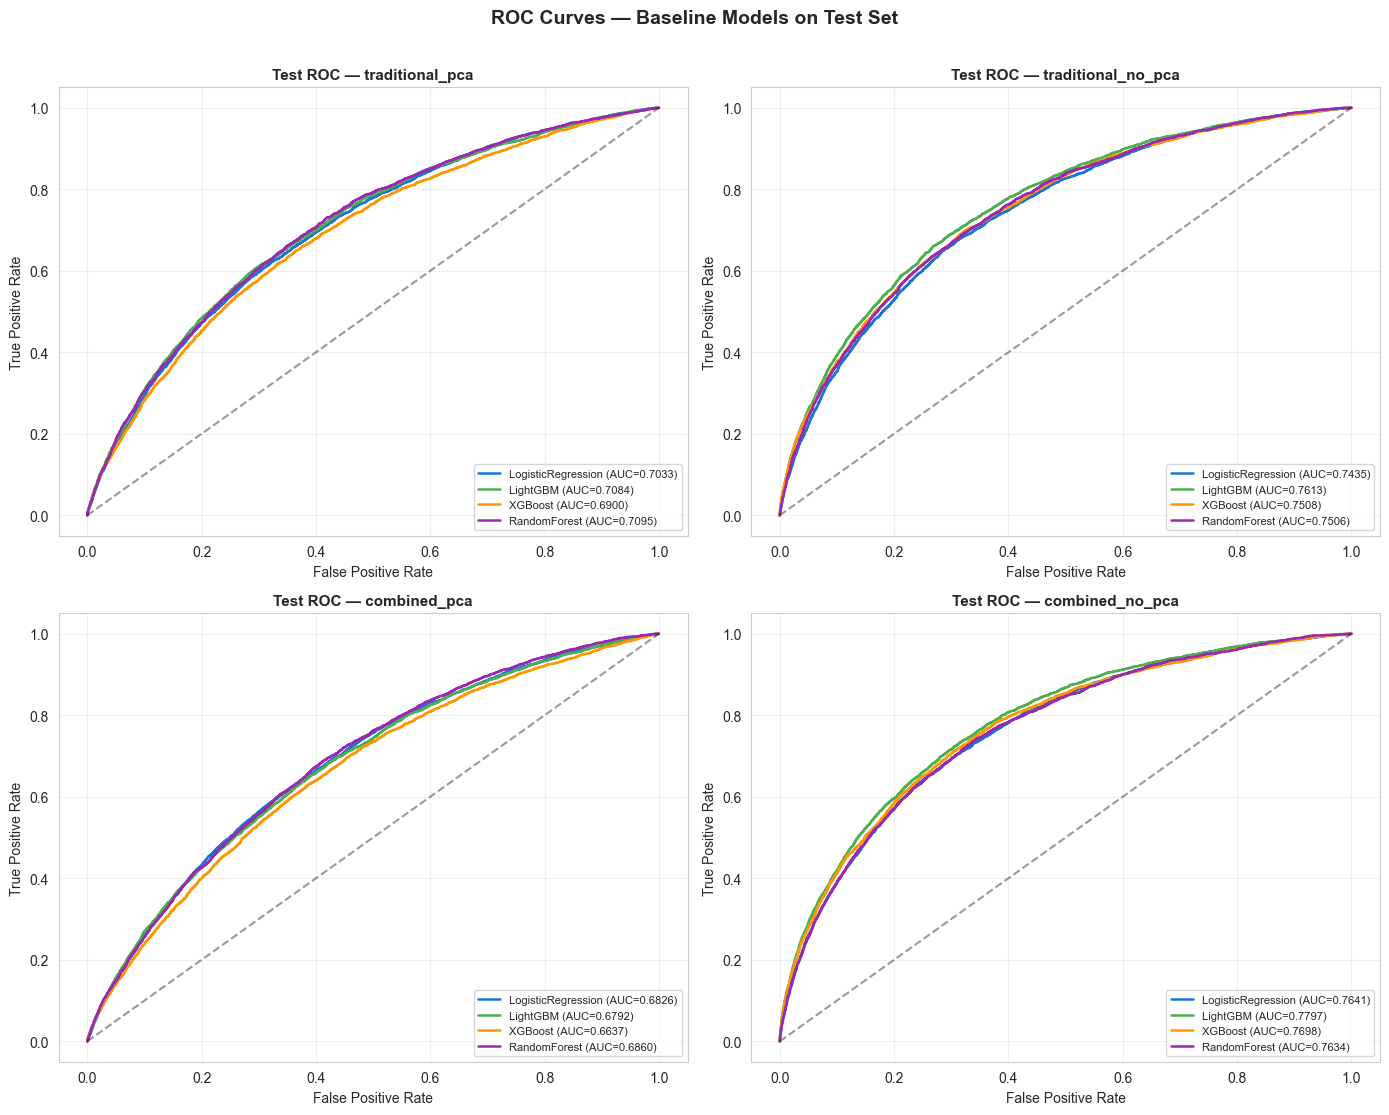

In [23]:
model_source = 'Tuned' if DO_HYPERTUNING else 'Baseline'
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for ax, (dataset_name, (probas, y_test)) in zip(axes.flatten(), test_probas.items()):
    for model_name, proba in probas.items():
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = roc_auc_score(y_test, proba)
        ax.plot(fpr, tpr, color=MODEL_COLORS[model_name], linewidth=1.8,
                label=f'{model_name} (AUC={auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Test ROC — {dataset_name}', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)

plt.suptitle(f'ROC Curves — {model_source} Models on Test Set', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 6.2b Test Confusion Matrices — Combined Datasets

> Confusion matrices for test set predictions using all 4 models on combined_no_pca and combined_pca datasets.

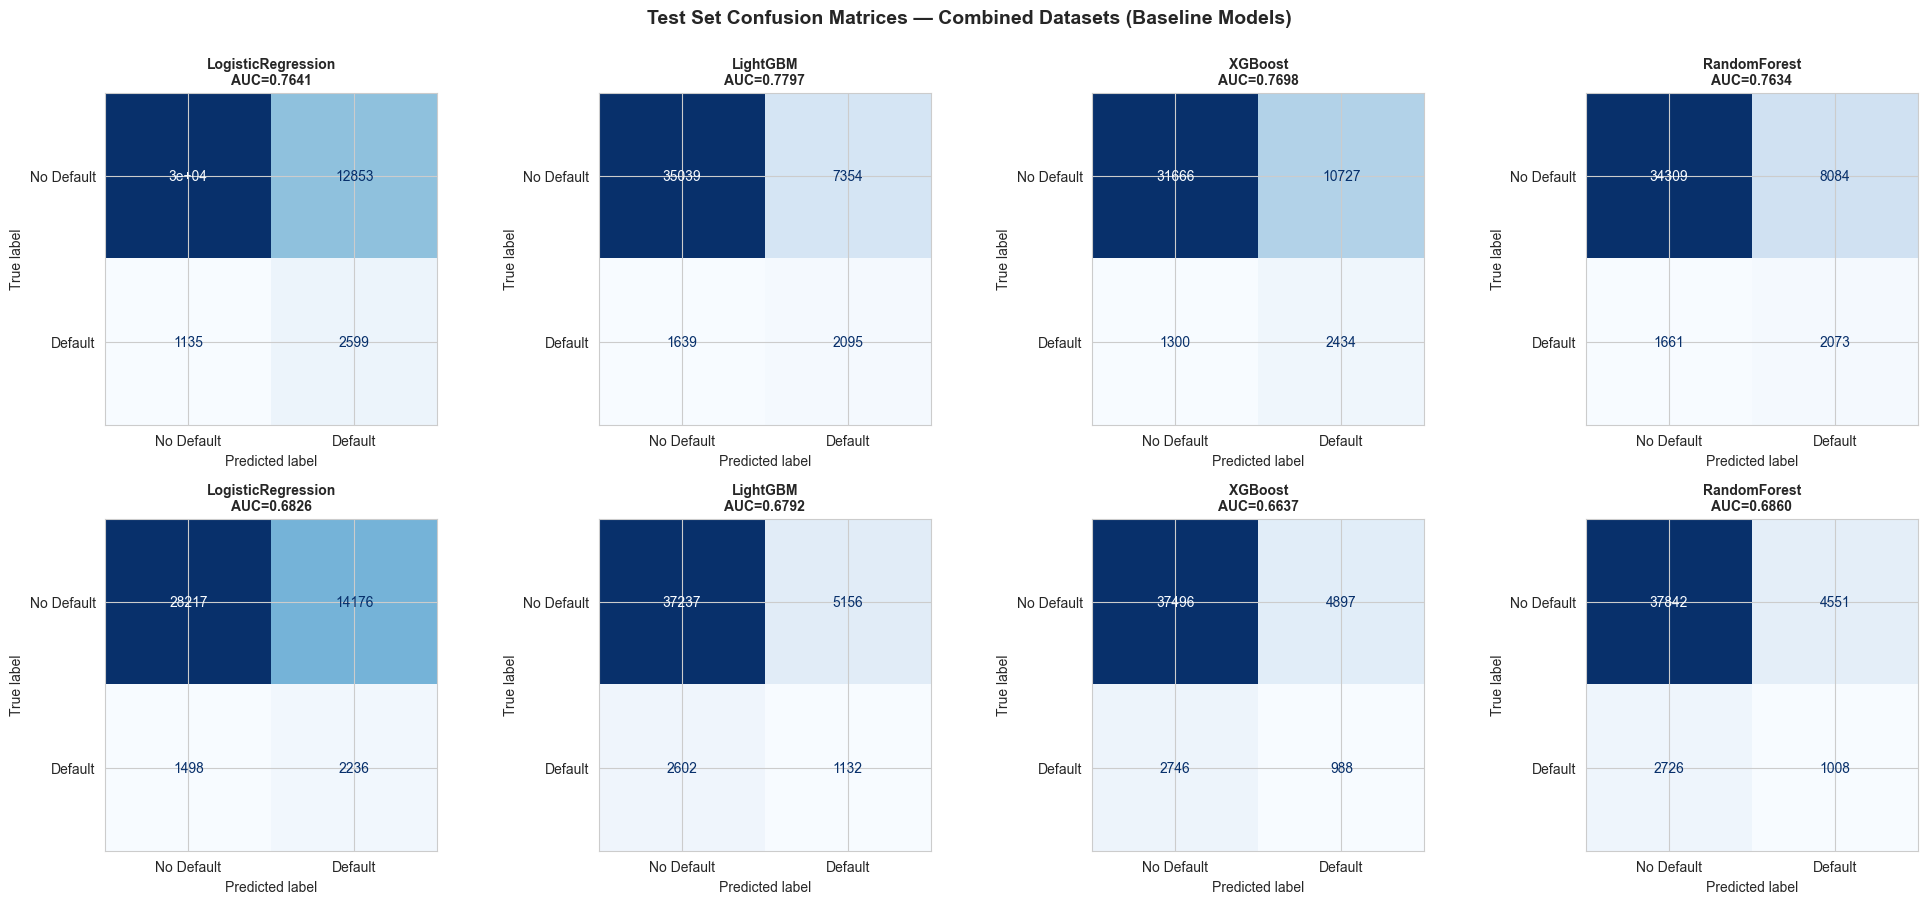

In [24]:
model_source = 'Tuned' if DO_HYPERTUNING else 'Baseline'
combined_datasets = ['combined_no_pca', 'combined_pca']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for row, dataset_name in enumerate(combined_datasets):
    probas, y_test = test_probas[dataset_name]
    for col, model_name in enumerate(['LogisticRegression', 'LightGBM', 'XGBoost', 'RandomForest']):
        ax = axes[row, col]
        proba = probas[model_name]
        preds = (proba >= 0.5).astype(int)
        cm = confusion_matrix(y_test, preds)
        disp = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        auc = test_results[dataset_name][model_name]['AUC']
        ax.set_title(f'{model_name}\nAUC={auc:.4f}', fontweight='bold', fontsize=10)

plt.suptitle(f'Test Set Confusion Matrices — Combined Datasets ({model_source} Models)', fontweight='bold', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

### 6.3 Final Test AUC Heatmap

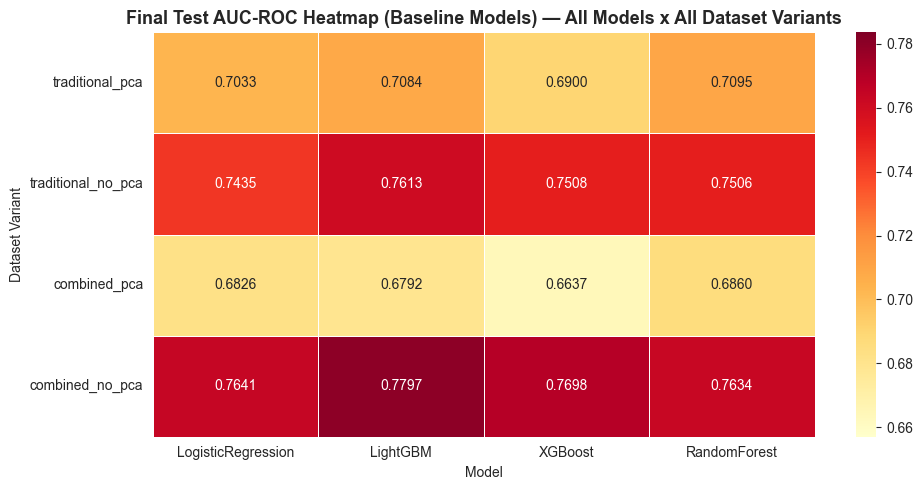

In [25]:
model_source = 'Tuned' if DO_HYPERTUNING else 'Baseline'
test_auc_matrix = pd.DataFrame(
    {ds: {m: test_results[ds][m]['AUC'] for m in test_results[ds]}
     for ds in test_results}
).T

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    test_auc_matrix.astype(float), annot=True, fmt='.4f',
    cmap='YlOrRd', ax=ax, linewidths=0.5,
    vmin=test_auc_matrix.values.min() * 0.99,
    vmax=test_auc_matrix.values.max() * 1.005
)
ax.set_title(f'Final Test AUC-ROC Heatmap ({model_source} Models) — All Models x All Dataset Variants', fontweight='bold', fontsize=13)
ax.set_xlabel('Model')
ax.set_ylabel('Dataset Variant')
plt.tight_layout()
plt.show()

### 6.4 Overall Best Model Summary

#### By AUC

In [26]:
model_source = 'Tuned' if DO_HYPERTUNING else 'Baseline'
summary_rows = []
for ds, rows in test_results.items():
    for model_name, metrics in rows.items():
        summary_rows.append({'Dataset': ds, 'Model': model_name, **metrics})

summary_df = pd.DataFrame(summary_rows).sort_values('AUC', ascending=False).reset_index(drop=True)
summary_df[['Recall', 'Precision', 'F1', 'Accuracy', 'AUC']] =     summary_df[['Recall', 'Precision', 'F1', 'Accuracy', 'AUC']].round(4)

print(f'=== TOP 10 MODEL-DATASET COMBINATIONS BY TEST AUC ({model_source} Models) ===')
display(summary_df.head(10).style.background_gradient(subset=['AUC'], cmap='YlOrRd'))

best_row = summary_df.iloc[0]
print(f'\nOverall Best: {best_row["Model"]} on {best_row["Dataset"]}')
print(f'  AUC={best_row["AUC"]:.4f}  F1={best_row["F1"]:.4f}  Recall={best_row["Recall"]:.4f}  Precision={best_row["Precision"]:.4f}')
print(f'  Models used: {model_source}')

=== TOP 10 MODEL-DATASET COMBINATIONS BY TEST AUC (Baseline Models) ===


,Dataset,Model,Recall,Precision,F1,Accuracy,AUC
0,combined_no_pca,LightGBM,0.561100,0.221700,0.317800,0.805000,0.779700
1,combined_no_pca,XGBoost,0.651800,0.184900,0.288100,0.739300,0.769800
2,combined_no_pca,LogisticRegression,0.696000,0.168200,0.270900,0.696800,0.764100
3,combined_no_pca,RandomForest,0.555200,0.204100,0.298500,0.788700,0.763400
4,traditional_no_pca,LightGBM,0.565600,0.198600,0.293900,0.780000,0.761300
5,traditional_no_pca,XGBoost,0.682900,0.162000,0.261900,0.688400,0.750800
6,traditional_no_pca,RandomForest,0.577400,0.187500,0.283100,0.763300,0.750600
7,traditional_no_pca,LogisticRegression,0.678600,0.159400,0.258100,0.684200,0.743500
8,traditional_pca,RandomForest,0.474600,0.171800,0.252300,0.772300,0.709500
9,traditional_pca,LightGBM,0.447500,0.181900,0.258700,0.792400,0.708400



Overall Best: LightGBM on combined_no_pca
  AUC=0.7797  F1=0.3178  Recall=0.5611  Precision=0.2217
  Models used: Baseline


#### By Recall

In [27]:
model_source = 'Tuned' if DO_HYPERTUNING else 'Baseline'
summary_rows = []
for ds, rows in test_results.items():
    for model_name, metrics in rows.items():
        summary_rows.append({'Dataset': ds, 'Model': model_name, **metrics})

summary_df = pd.DataFrame(summary_rows).sort_values('Recall', ascending=False).reset_index(drop=True)
summary_df[['Recall', 'Precision', 'F1', 'Accuracy', 'AUC']] =     summary_df[['Recall', 'Precision', 'F1', 'Accuracy', 'AUC']].round(4)

print(f'=== TOP 10 MODEL-DATASET COMBINATIONS BY TEST RECALL ({model_source} Models) ===')
display(summary_df.head(10).style.background_gradient(subset=['Recall'], cmap='YlOrRd'))

best_row = summary_df.iloc[0]
print(f'\nOverall Best: {best_row["Model"]} on {best_row["Dataset"]}')
print(f'  AUC={best_row["AUC"]:.4f}  F1={best_row["F1"]:.4f}  Recall={best_row["Recall"]:.4f}  Precision={best_row["Precision"]:.4f}')
print(f'  Models used: {model_source}')

=== TOP 10 MODEL-DATASET COMBINATIONS BY TEST RECALL (Baseline Models) ===


,Dataset,Model,Recall,Precision,F1,Accuracy,AUC
0,combined_no_pca,LogisticRegression,0.696000,0.168200,0.270900,0.696800,0.764100
1,traditional_no_pca,XGBoost,0.682900,0.162000,0.261900,0.688400,0.750800
2,traditional_no_pca,LogisticRegression,0.678600,0.159400,0.258100,0.684200,0.743500
3,combined_no_pca,XGBoost,0.651800,0.184900,0.288100,0.739300,0.769800
4,traditional_pca,LogisticRegression,0.625900,0.144000,0.234100,0.668500,0.703300
5,combined_pca,LogisticRegression,0.598800,0.136200,0.222000,0.660200,0.682600
6,traditional_no_pca,RandomForest,0.577400,0.187500,0.283100,0.763300,0.750600
7,traditional_no_pca,LightGBM,0.565600,0.198600,0.293900,0.780000,0.761300
8,combined_no_pca,LightGBM,0.561100,0.221700,0.317800,0.805000,0.779700
9,combined_no_pca,RandomForest,0.555200,0.204100,0.298500,0.788700,0.763400



Overall Best: LogisticRegression on combined_no_pca
  AUC=0.7641  F1=0.2709  Recall=0.6960  Precision=0.1682
  Models used: Baseline


## 7. SHAP Analysis — All Models on Best Dataset

> Each model's SHAP is computed on fold 0 of its ensemble (all folds share the same feature space).  
> **LogisticRegression** uses `shap.LinearExplainer` (fast exact solution).  
> **Tree models** use `shap.TreeExplainer` with interventional perturbation.

In [28]:
shap_dataset = best_dataset
train_df_shap, val_df_shap, _ = datasets[shap_dataset]
X_train_shap, y_train_shap = xy(train_df_shap)
X_val_shap,   y_val_shap   = xy(val_df_shap)

N_SHAP_BACKGROUND = 500
N_SHAP_EXPLAIN    = 1000

rng     = np.random.default_rng(SEED)
bg_idx  = rng.choice(len(X_train_shap), size=min(N_SHAP_BACKGROUND, len(X_train_shap)), replace=False)
exp_idx = rng.choice(len(X_val_shap),   size=min(N_SHAP_EXPLAIN,    len(X_val_shap)),   replace=False)

X_bg  = X_train_shap.iloc[bg_idx]
X_exp = X_val_shap.iloc[exp_idx]

all_shap_values = {}

for model_name, ensemble in baseline_fitted[shap_dataset].items():
    model = ensemble[0]
    print(f'Computing SHAP for {model_name}...')

    if model_name in ('LightGBM', 'XGBoost', 'RandomForest'):
        explainer = shap.TreeExplainer(
            model, data=X_bg,
            feature_perturbation='interventional',
            model_output='probability'
        )
        sv = explainer(X_exp)
    else:
        explainer = shap.LinearExplainer(model, X_bg, feature_perturbation='interventional')
        sv_raw = explainer.shap_values(X_exp)
        if isinstance(sv_raw, list) and len(sv_raw) == 2:
            sv_raw = sv_raw[1]
        expected_value = explainer.expected_value
        if isinstance(expected_value, (list, np.ndarray)):
            expected_value = expected_value[1]
        sv = shap.Explanation(
            values=sv_raw,
            base_values=np.full(len(X_exp), expected_value),
            data=X_exp.values,
            feature_names=X_exp.columns.tolist()
        )

    if hasattr(sv, 'values') and len(sv.values.shape) == 3:
        sv.values = sv.values[:, :, 1]
        if hasattr(sv, 'base_values') and isinstance(sv.base_values, np.ndarray) and len(sv.base_values.shape) > 0:
            if len(sv.base_values.shape) > 1 or (len(sv.base_values.shape) == 1 and len(sv.base_values) == 2):
                sv.base_values = sv.base_values[1] if len(sv.base_values) == 2 else sv.base_values[0]
    
    all_shap_values[model_name] = sv
    print(f'  Done — {X_exp.shape[1]} features, {len(X_exp)} samples.')

print('\nSHAP computation complete for all models.')

Computing SHAP for LogisticRegression...
  Done — 119 features, 1000 samples.
Computing SHAP for LightGBM...


100%|===================| 998/1000 [01:58<00:00]        

  Done — 119 features, 1000 samples.
Computing SHAP for XGBoost...


100%|===================| 998/1000 [03:16<00:00]        

  Done — 119 features, 1000 samples.
Computing SHAP for RandomForest...


100%|===================| 1999/2000 [07:56<00:00]        

  Done — 119 features, 1000 samples.

SHAP computation complete for all models.


### 7.1 SHAP Beeswarm — All Models

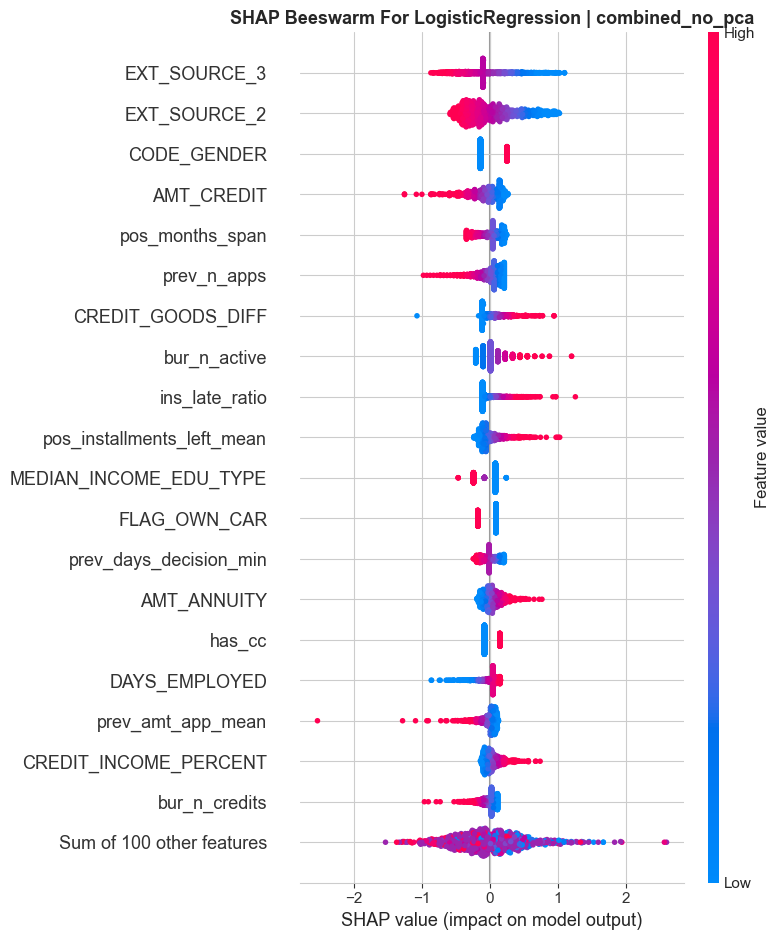

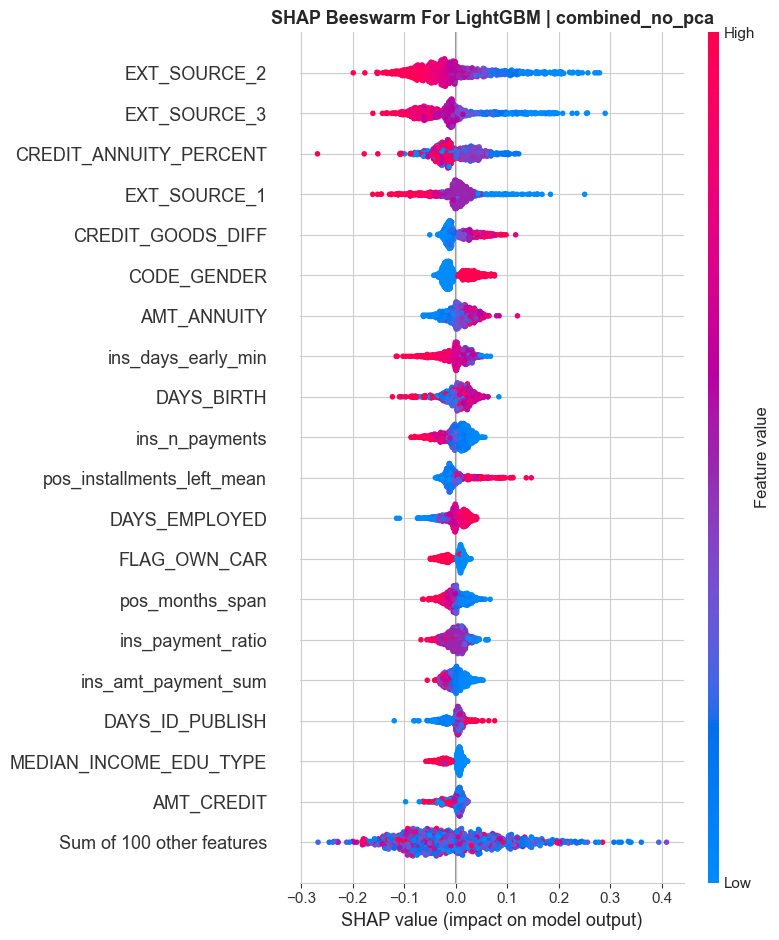

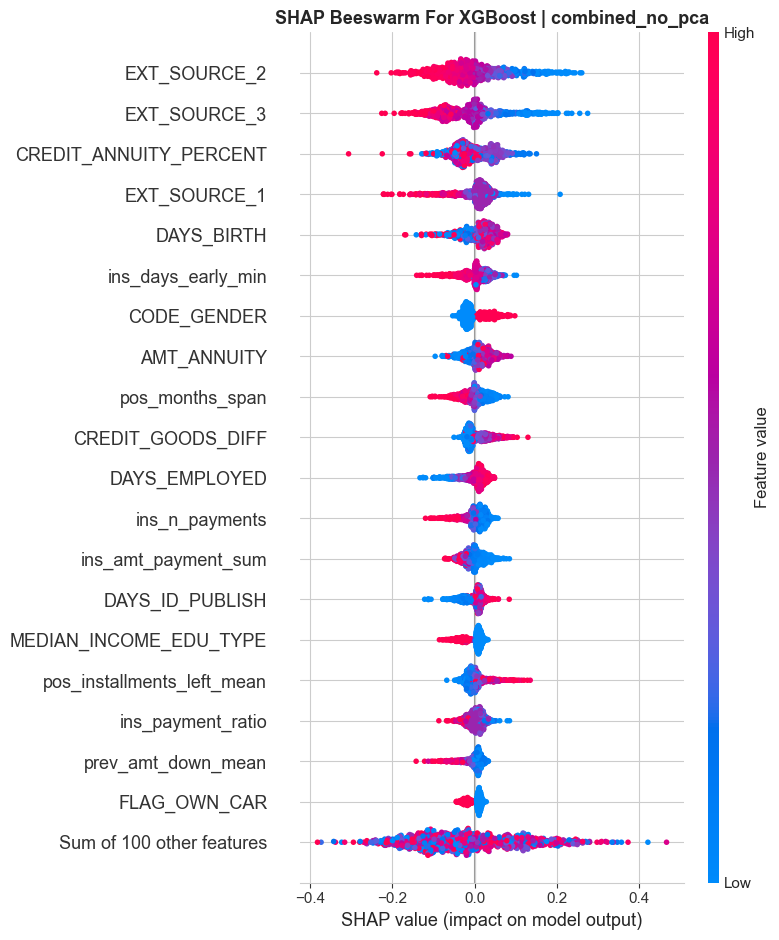

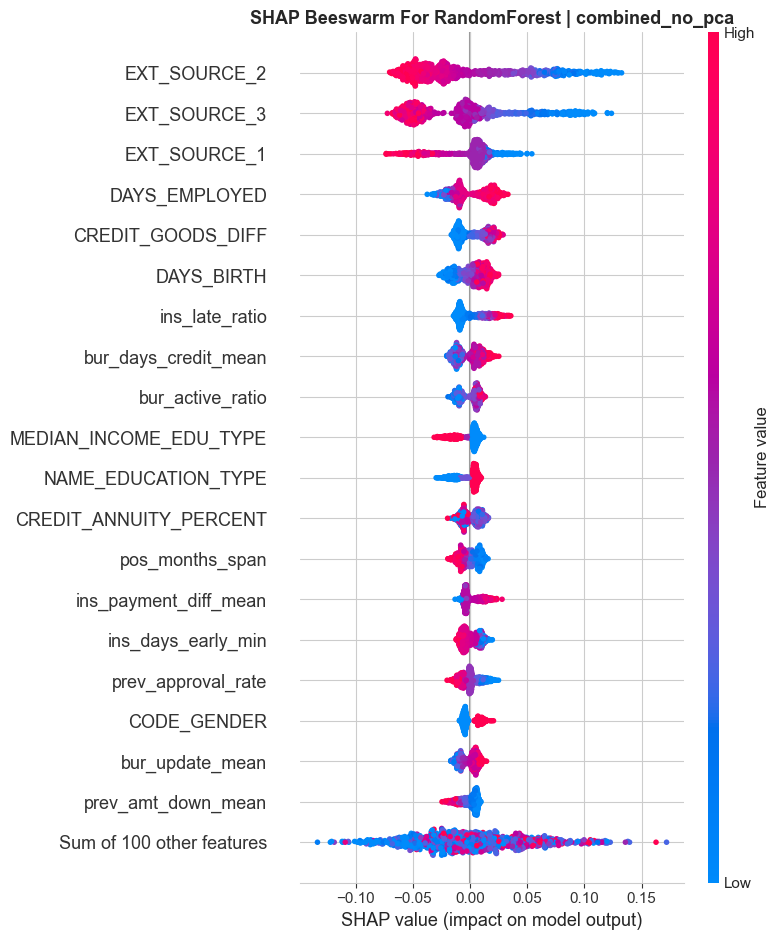

In [29]:
for model_name, sv in all_shap_values.items():
    plt.figure(figsize=(10, 9))
    shap.plots.beeswarm(sv, max_display=20, show=False)
    plt.title(f'SHAP Beeswarm For {model_name} | {shap_dataset}', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()

### 7.2 SHAP Feature Importance Bar — All Models

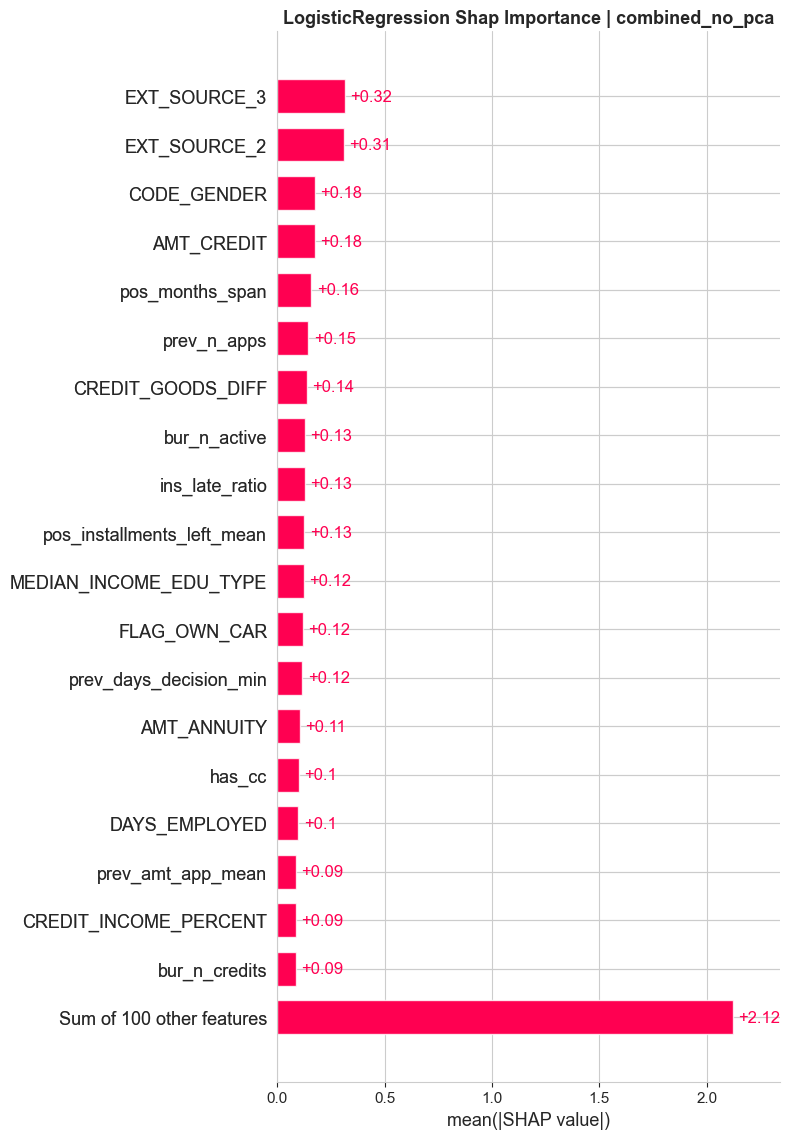

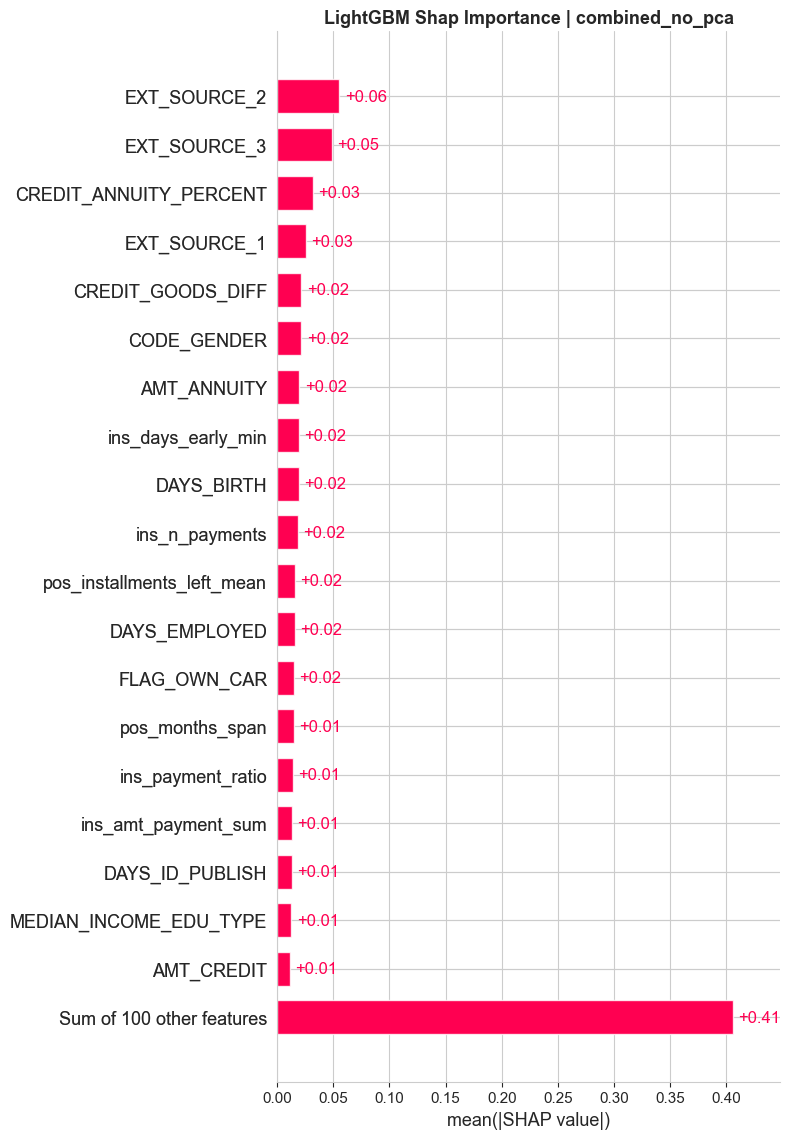

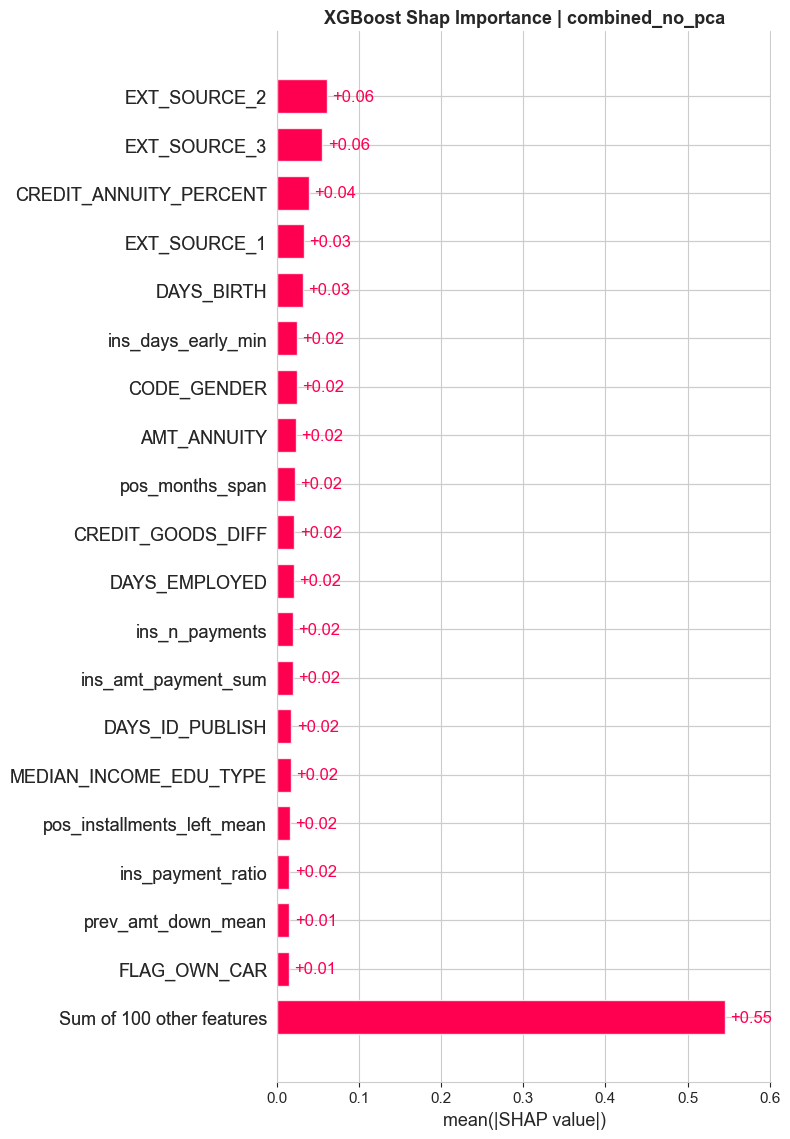

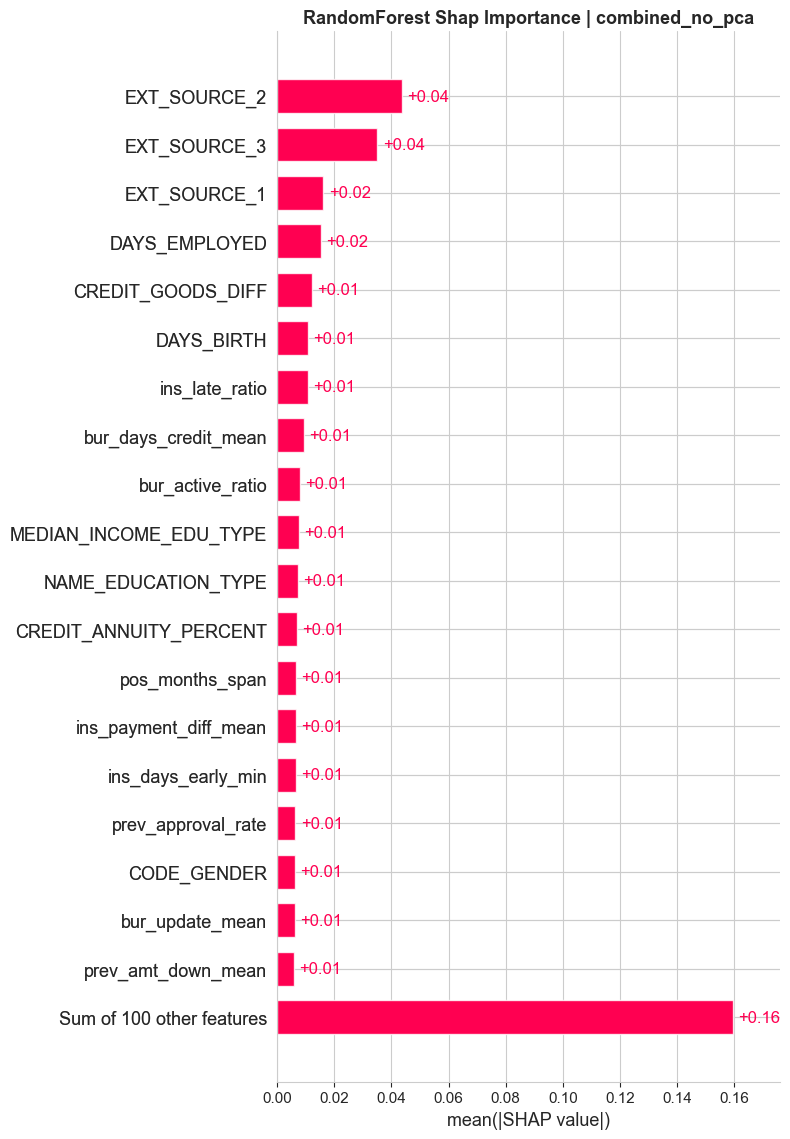

In [30]:
for model_name, sv in all_shap_values.items():
    plt.figure(figsize=(9, 8))
    shap.plots.bar(sv, max_display=20, show=False)
    plt.title(f'{model_name} Shap Importance | {shap_dataset}', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()

### 7.3 SHAP vs Native Feature Importance — All Models

> LR native importance = avg absolute coefficient across ensemble folds (normalised).

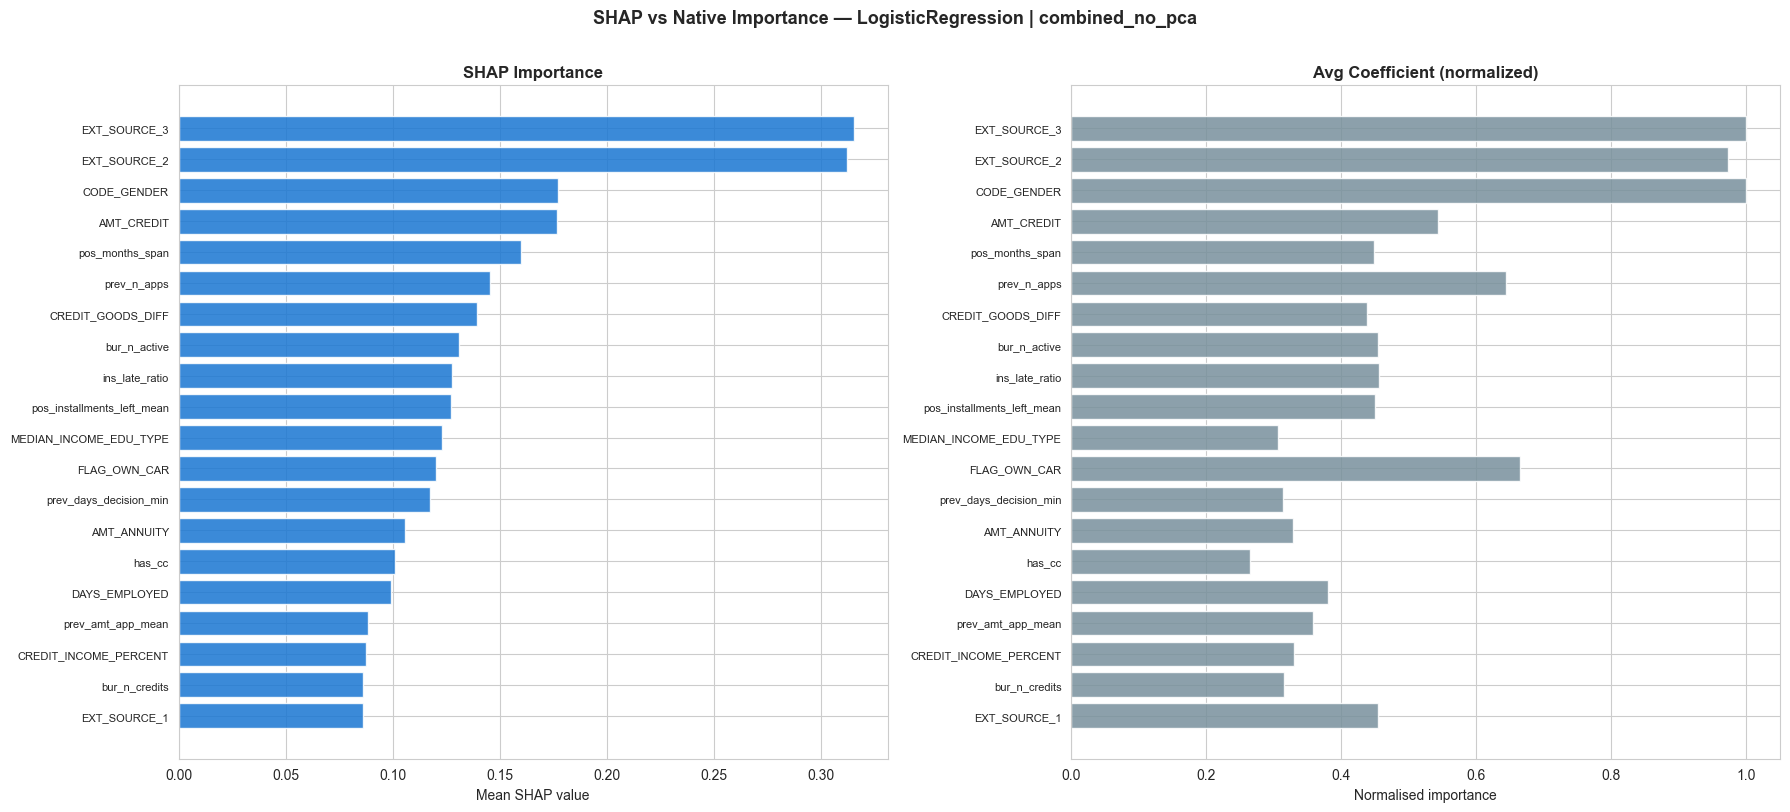

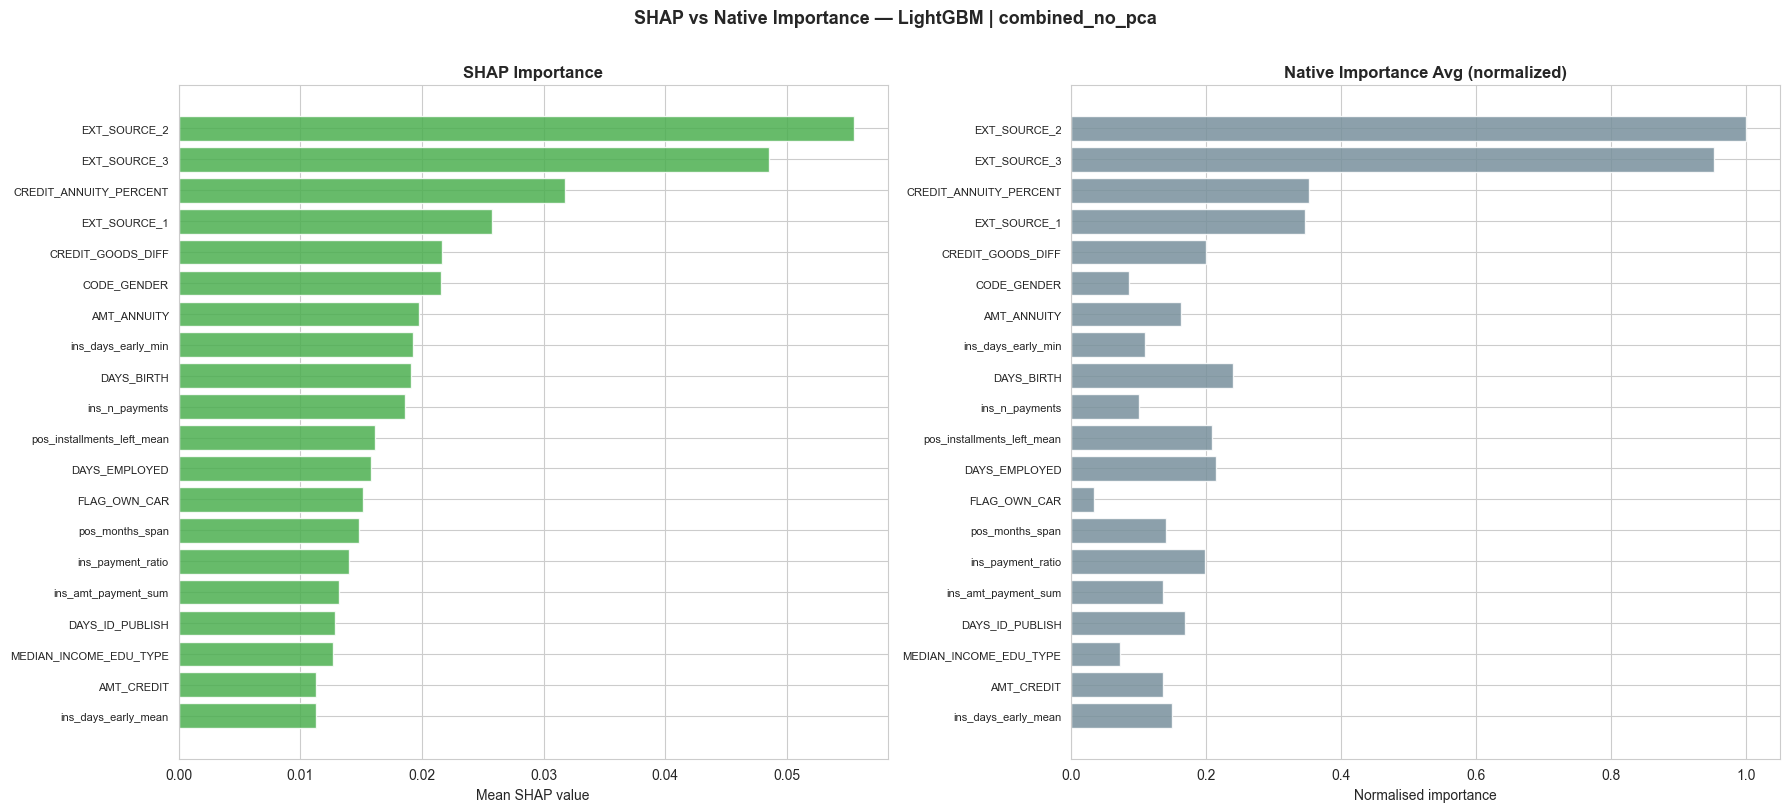

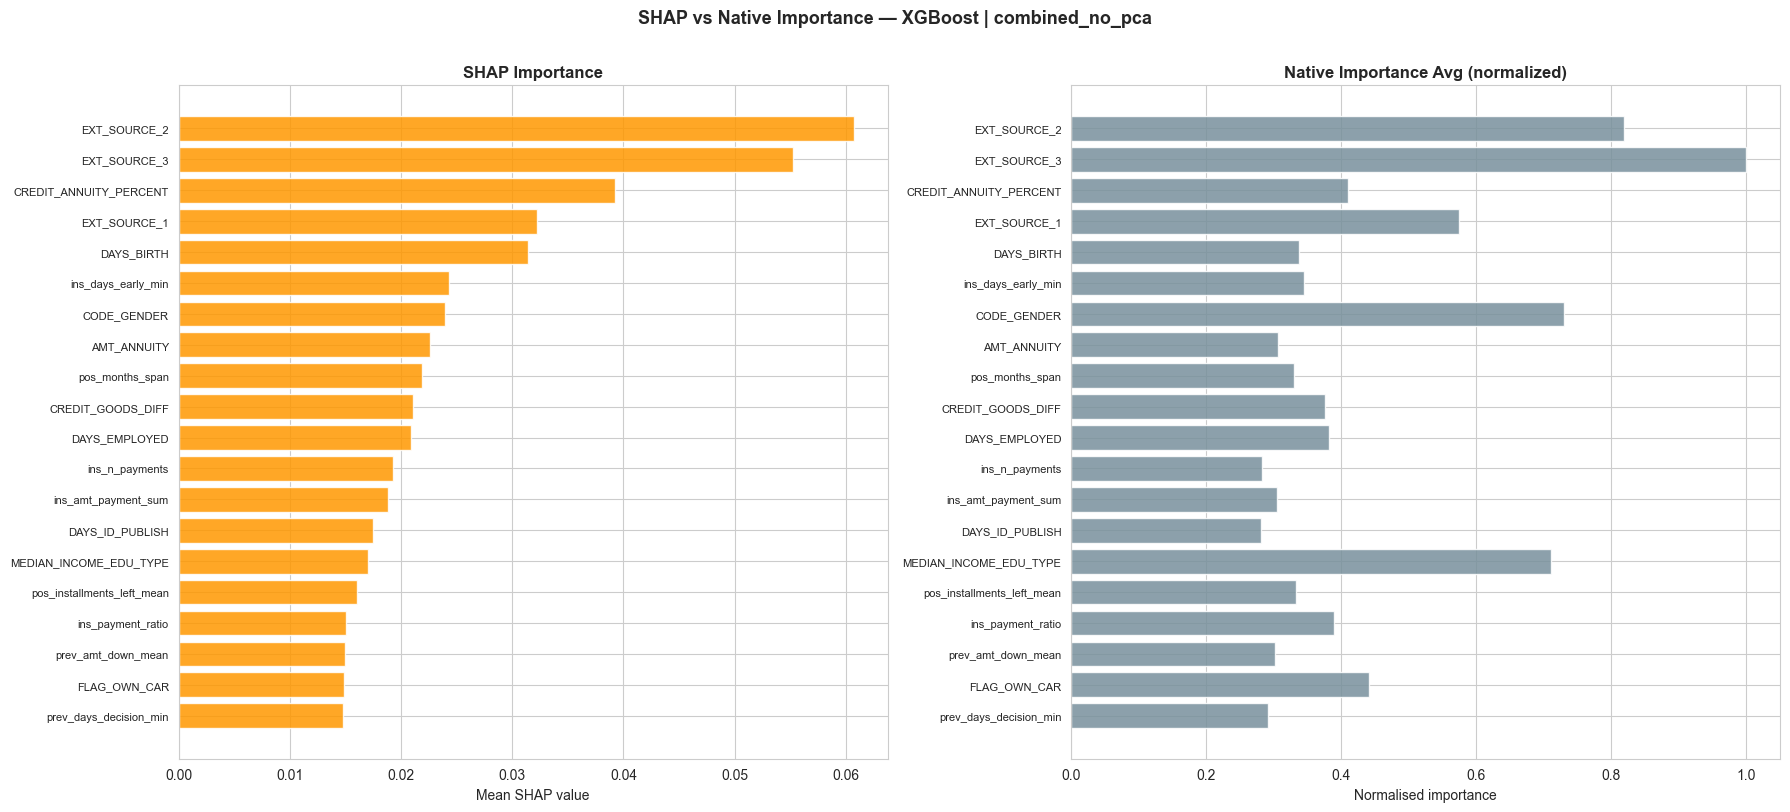

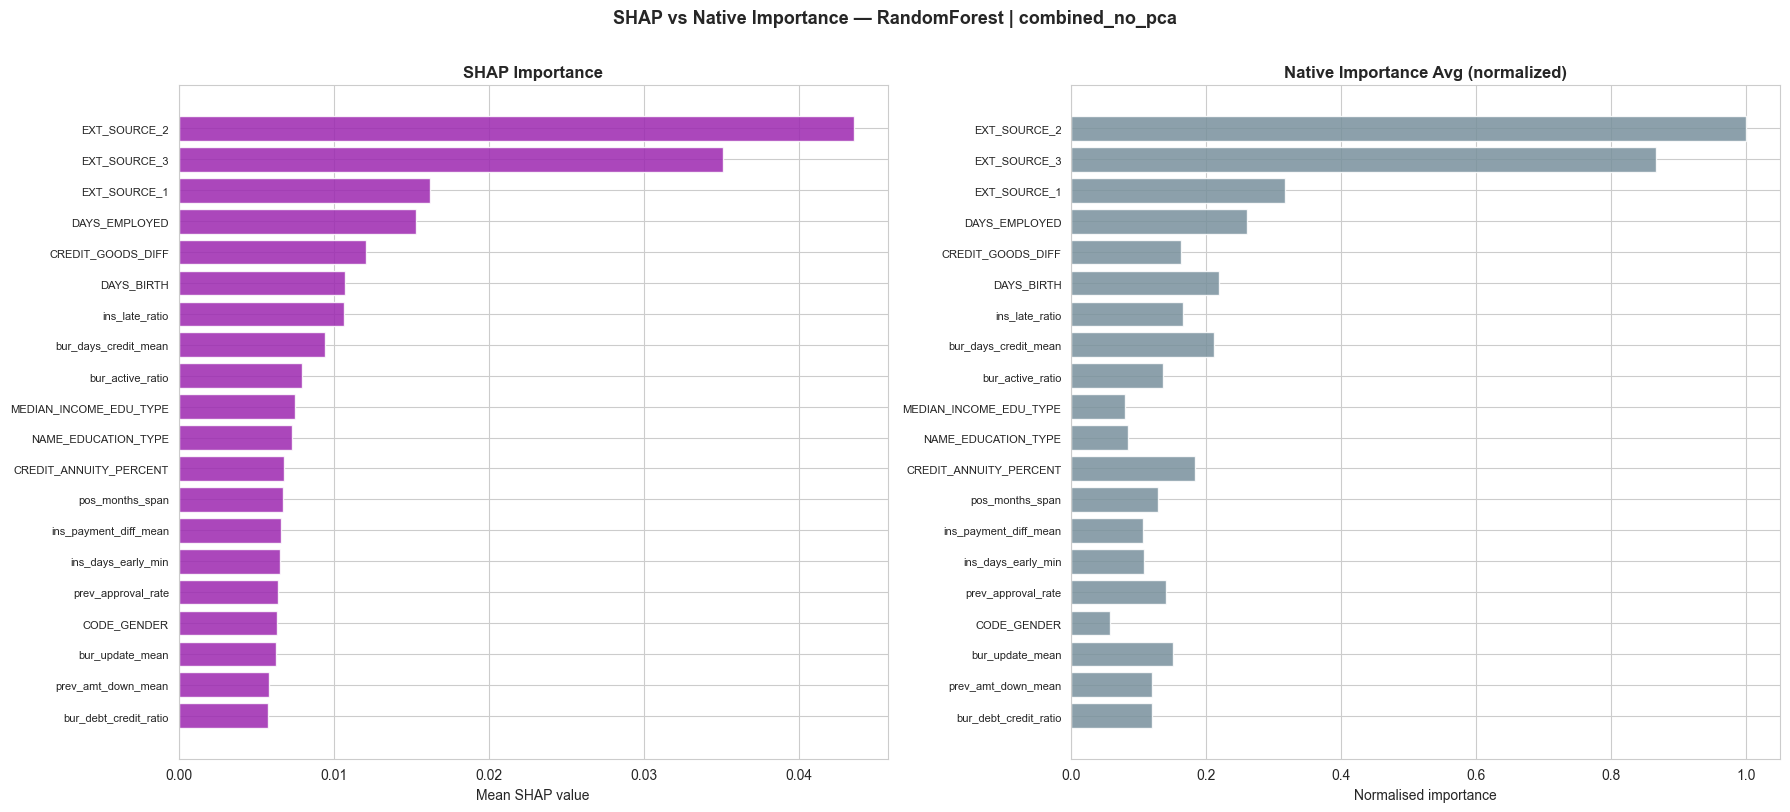

In [31]:
for model_name, sv in all_shap_values.items():
    ensemble = baseline_fitted[shap_dataset][model_name]

    shap_imp = pd.Series(
        np.abs(sv.values).mean(axis=0), index=X_exp.columns
    ).sort_values(ascending=False).head(20)

    if model_name == 'LogisticRegression':
        avg_coef   = np.mean([m.coef_[0] for m in ensemble], axis=0)
        native_imp = pd.Series(np.abs(avg_coef), index=X_train_shap.columns).reindex(shap_imp.index)
        native_label = 'Avg Coefficient (normalized)'
    else:
        avg_fi     = np.mean([m.feature_importances_ for m in ensemble], axis=0)
        native_imp = pd.Series(avg_fi, index=X_train_shap.columns).reindex(shap_imp.index)
        native_label = f'Native Importance Avg (normalized)'

    shap_sorted   = shap_imp.sort_values()
    native_sorted = native_imp[shap_sorted.index]
    native_norm   = native_sorted / native_sorted.max()

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    axes[0].barh(range(len(shap_sorted)), shap_sorted.values,
                 color=MODEL_COLORS[model_name], edgecolor='white', alpha=0.85)
    axes[0].set_yticks(range(len(shap_sorted)))
    axes[0].set_yticklabels([n[:40] for n in shap_sorted.index], fontsize=8)
    axes[0].set_title('SHAP Importance', fontweight='bold')
    axes[0].set_xlabel('Mean SHAP value')

    axes[1].barh(range(len(native_norm)), native_norm.values,
                 color='#78909c', edgecolor='white', alpha=0.85)
    axes[1].set_yticks(range(len(native_norm)))
    axes[1].set_yticklabels([n[:40] for n in native_norm.index], fontsize=8)
    axes[1].set_title(native_label, fontweight='bold')
    axes[1].set_xlabel('Normalised importance')

    plt.suptitle(f'SHAP vs Native Importance — {model_name} | {shap_dataset}',
                 fontweight='bold', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

### 7.4 SHAP Dependence Plots — Top 4 Features per Model

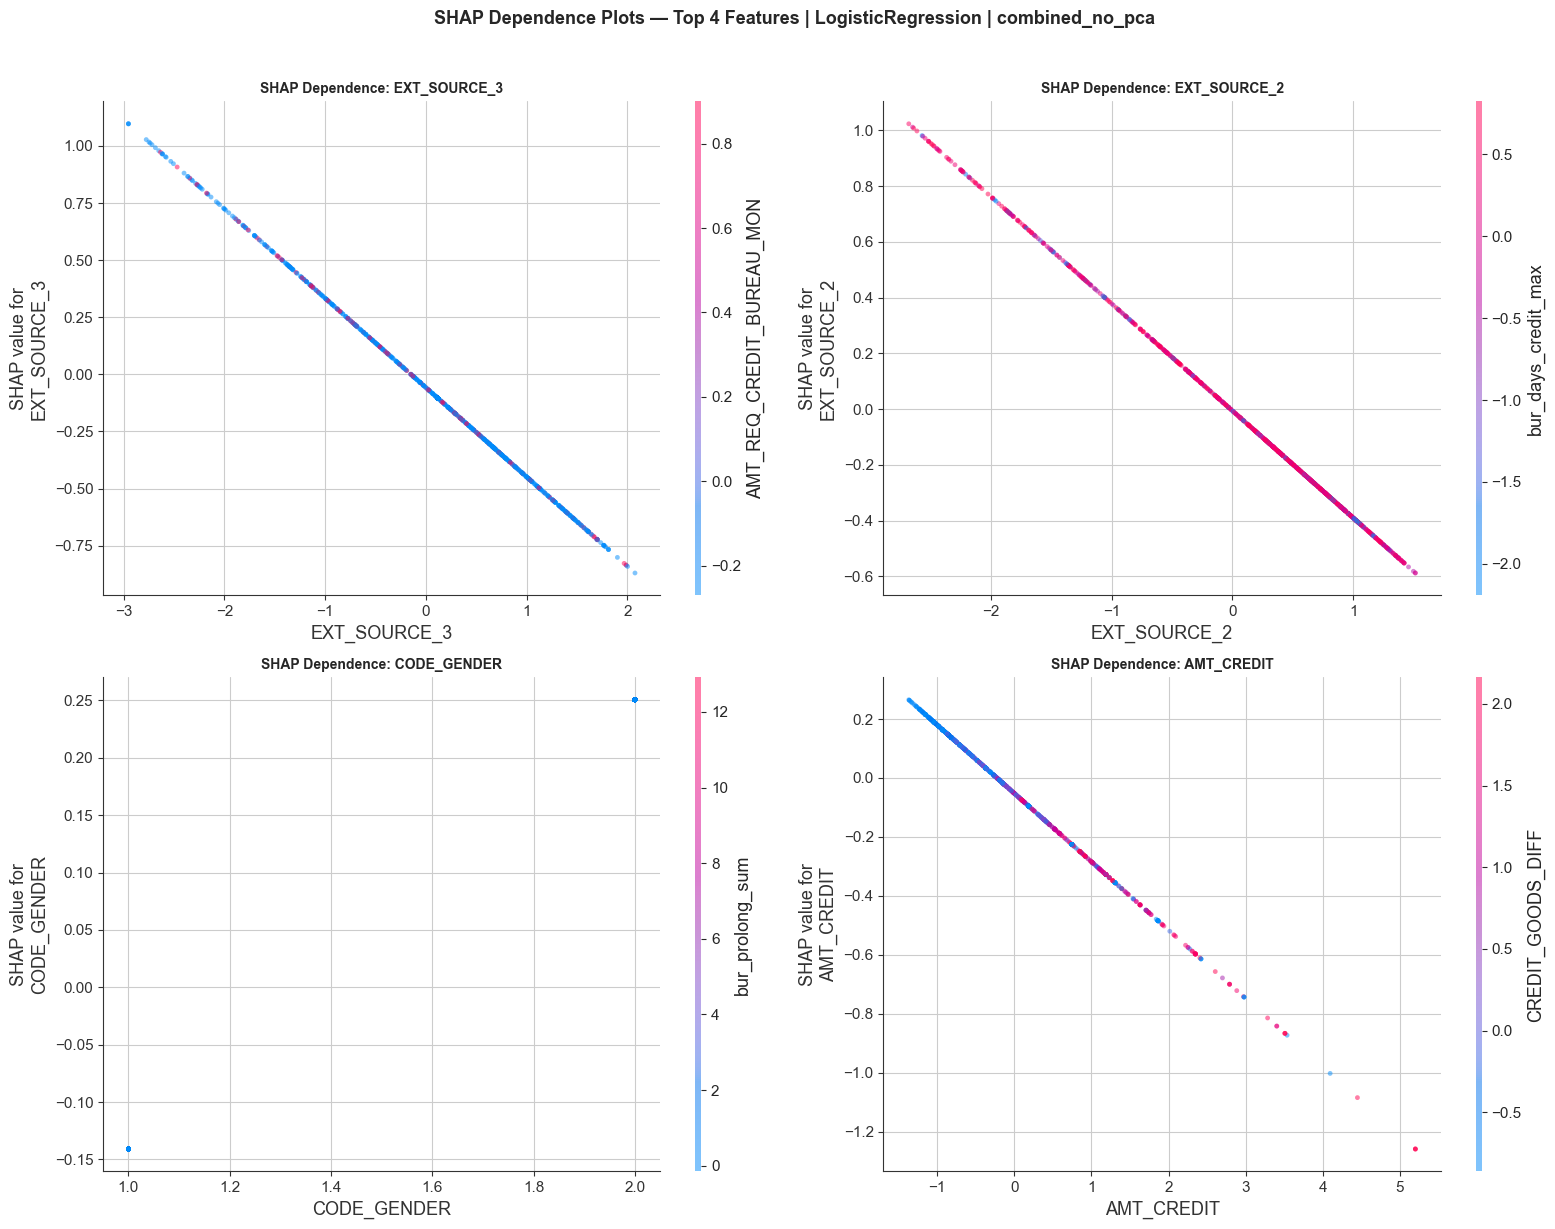

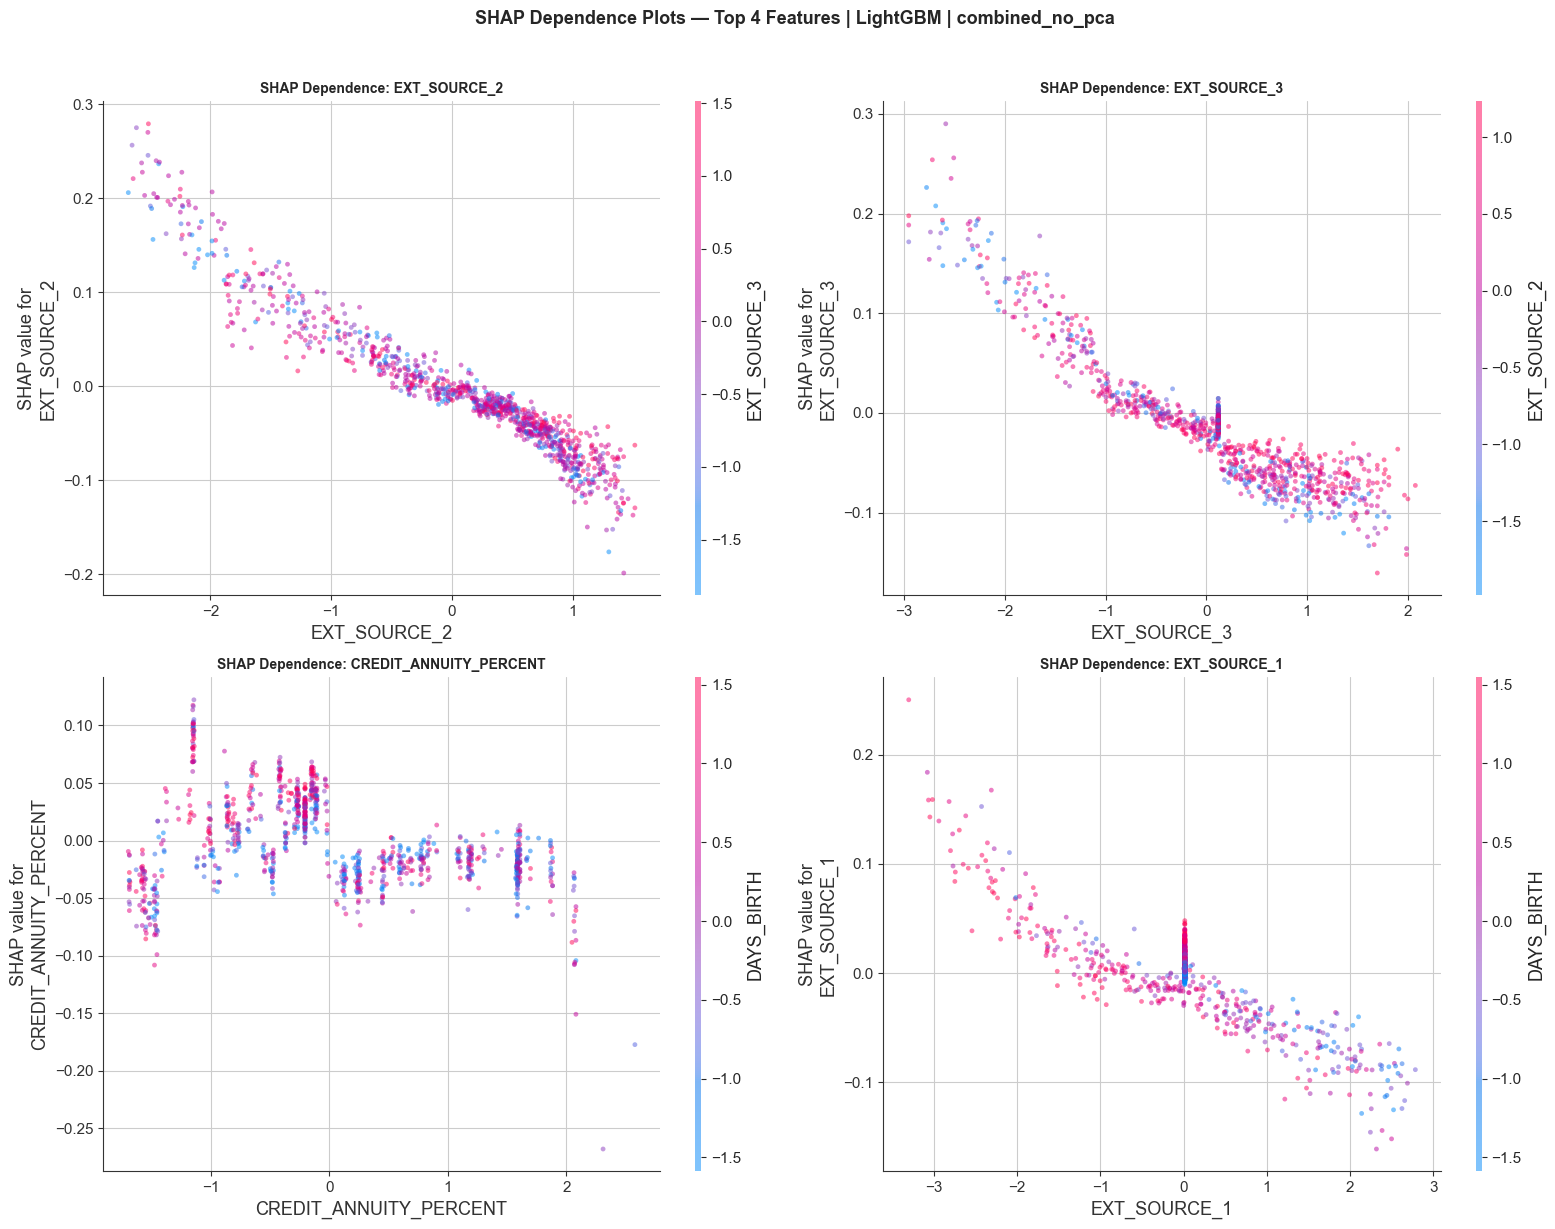

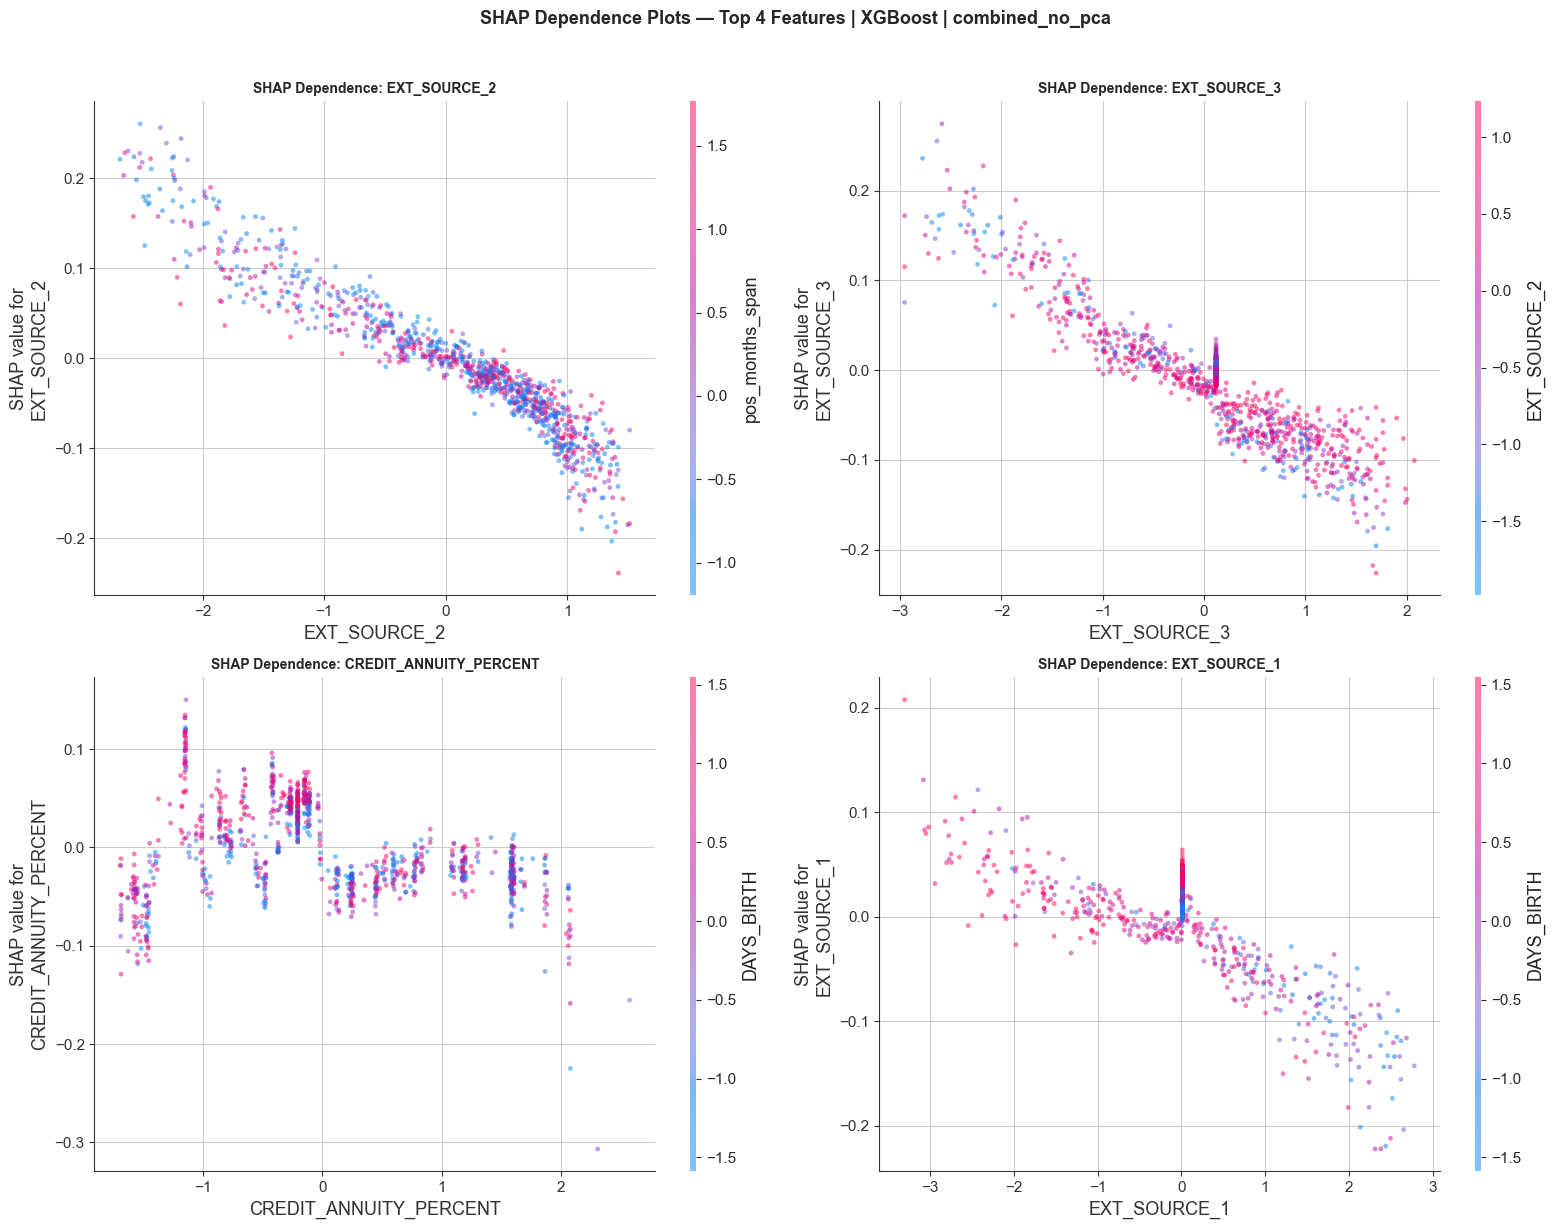

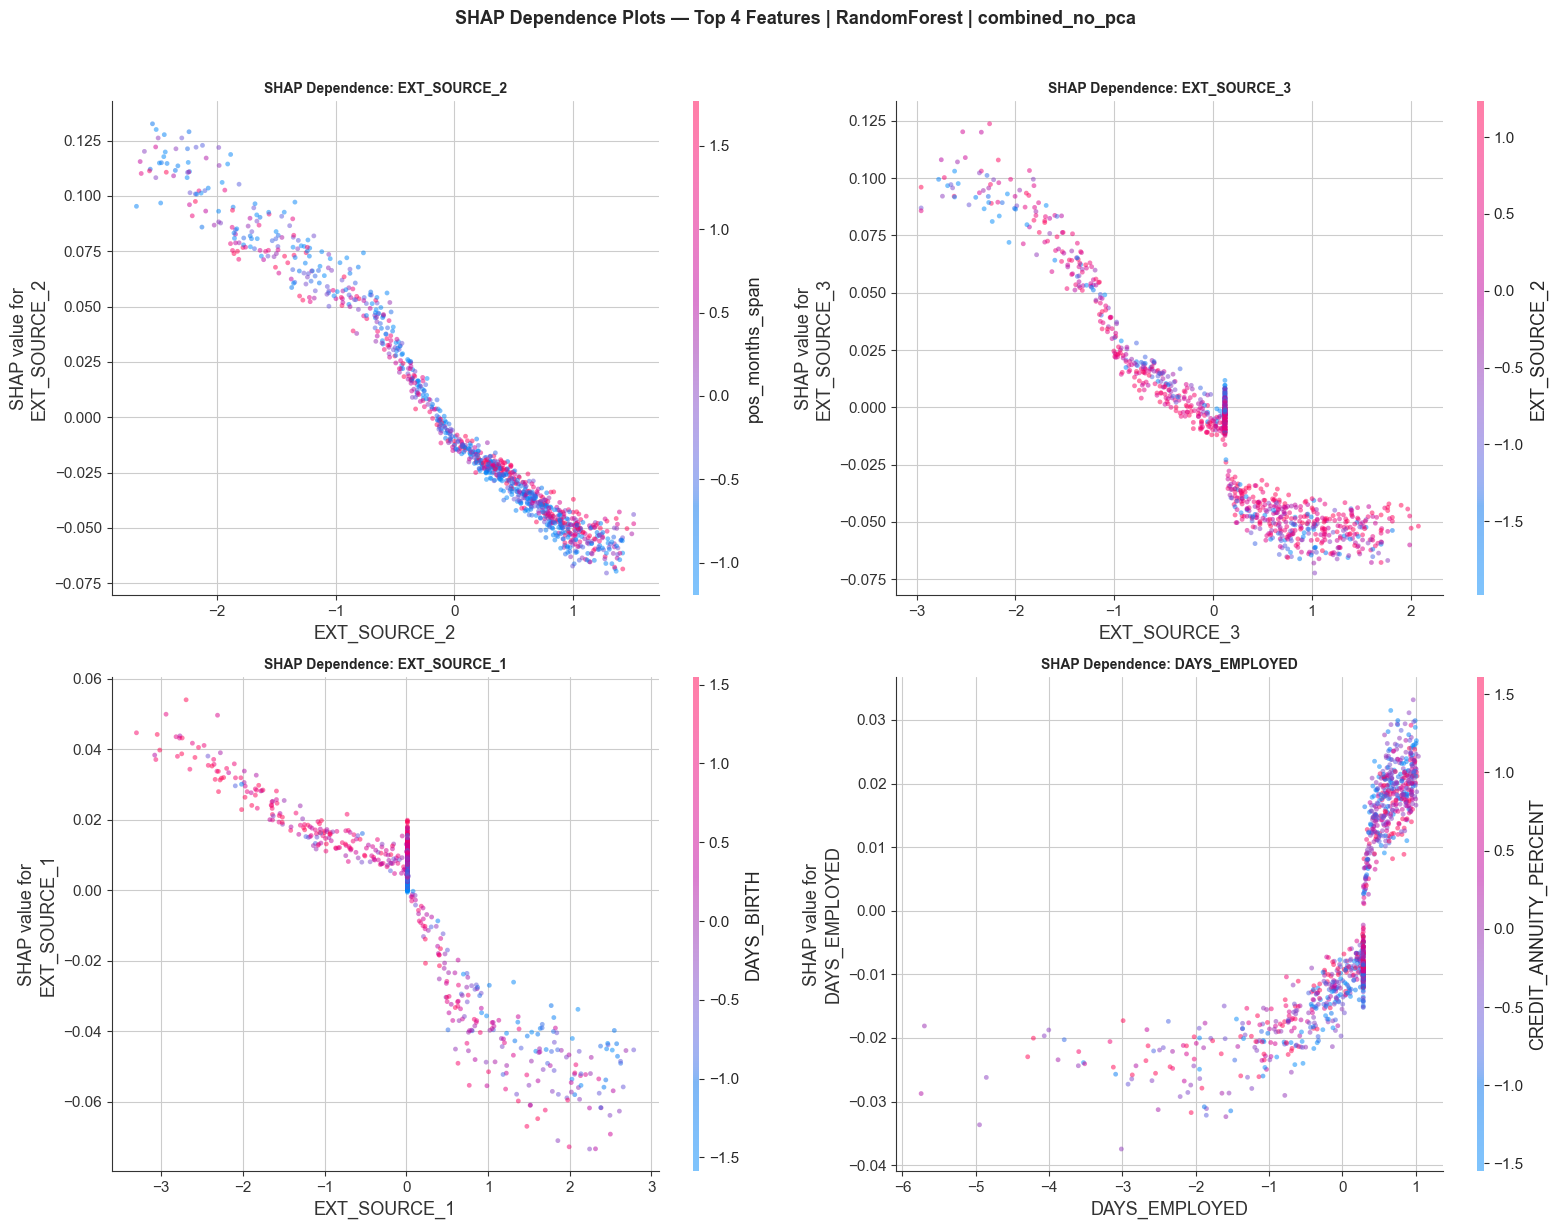

In [32]:
for model_name, sv in all_shap_values.items():
    top4 = pd.Series(
        np.abs(sv.values).mean(axis=0), index=X_exp.columns
    ).nlargest(4).index.tolist()

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    for ax, feat in zip(axes.flatten(), top4):
        feat_idx = X_exp.columns.tolist().index(feat)
        shap.dependence_plot(
            feat_idx, sv.values, X_exp,
            interaction_index='auto', ax=ax, show=False,
            dot_size=12, alpha=0.5
        )
        ax.set_title(f'SHAP Dependence: {feat[:40]}', fontweight='bold', fontsize=10)

    plt.suptitle(f'SHAP Dependence Plots — Top 4 Features | {model_name} | {shap_dataset}',
                 fontweight='bold', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

### 7.5 SHAP Waterfall — Top 3 High-Risk Predictions per Model

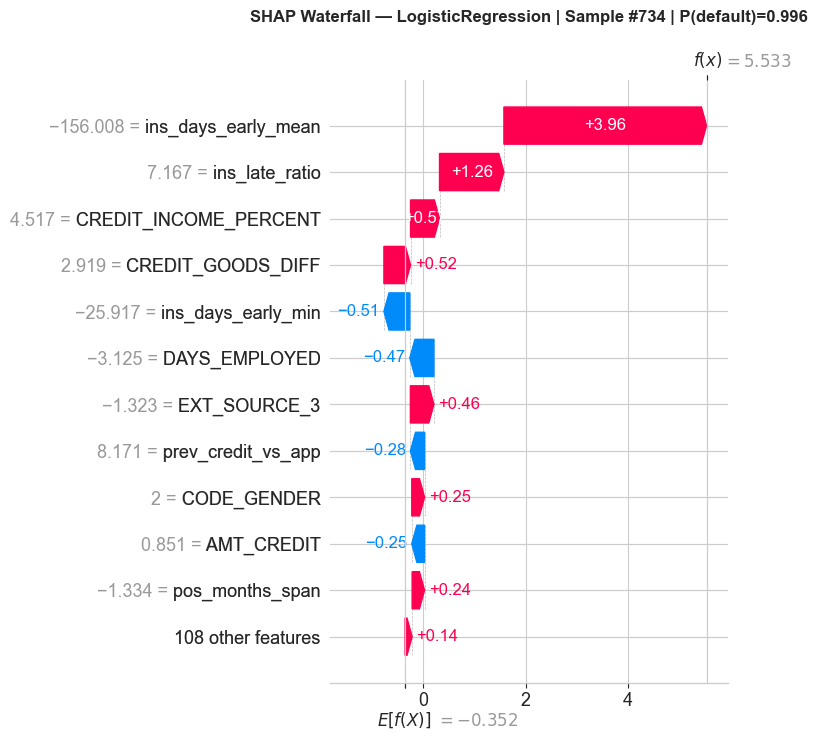

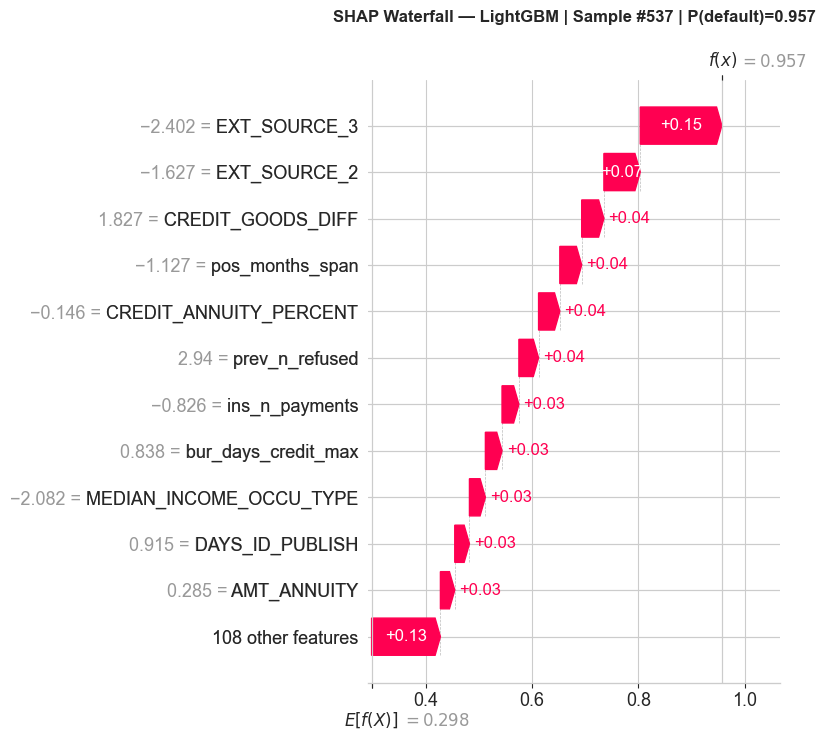

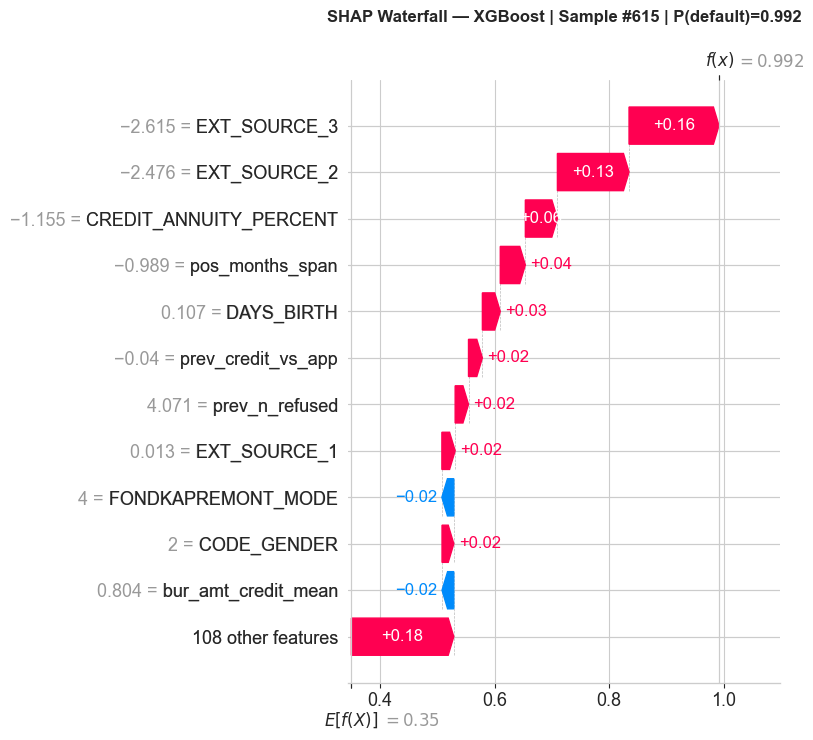

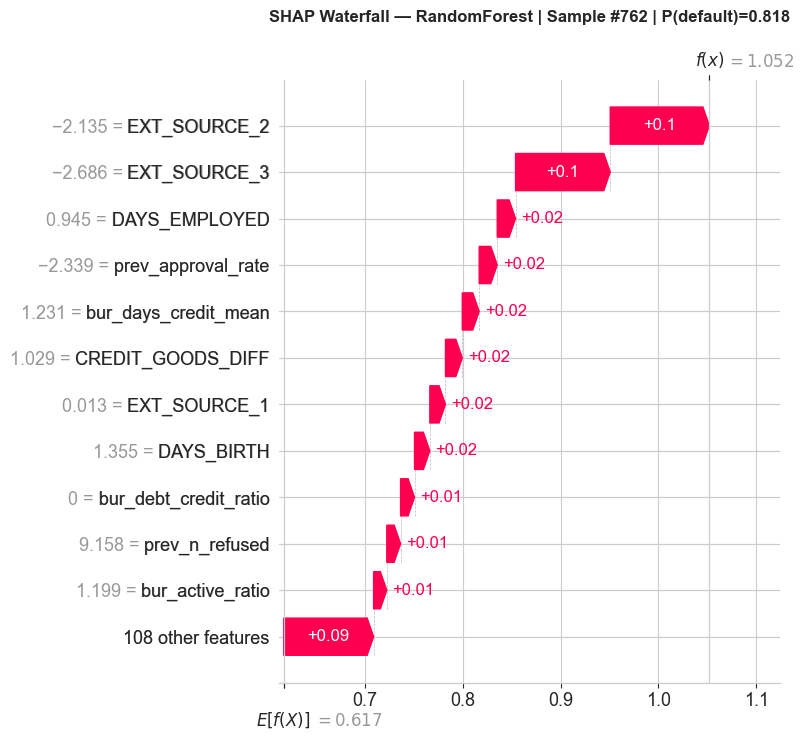

In [33]:
for model_name, sv in all_shap_values.items():
    model        = baseline_fitted[shap_dataset][model_name][0]
    proba_exp    = model.predict_proba(X_exp)[:, 1]
    top_risk_idx = np.argsort(proba_exp)[-1:][::-1]

    for plot_i, sample_i in enumerate(top_risk_idx):
        fig, ax = plt.subplots(1, 1, figsize=(10, 7))
        sv_single = sv[sample_i]
        if hasattr(sv_single, 'base_values'):
            if hasattr(sv_single.base_values, '__len__'):
                sv_single.base_values = float(sv_single.base_values[0]) if len(sv_single.base_values) > 0 else float(sv_single.base_values)
            else:
                sv_single.base_values = float(sv_single.base_values)
        shap.plots.waterfall(sv_single, max_display=12, show=False)
        plt.title(
            f'SHAP Waterfall — {model_name} | Sample #{sample_i} | P(default)={proba_exp[sample_i]:.3f}',
            fontweight='bold', fontsize=12, pad=20
        )
        plt.tight_layout()
        plt.show()


### 7.6 SHAP Heatmap — All Models

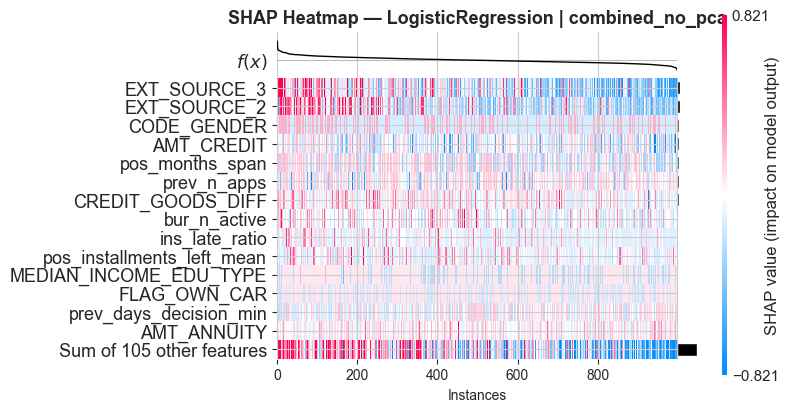

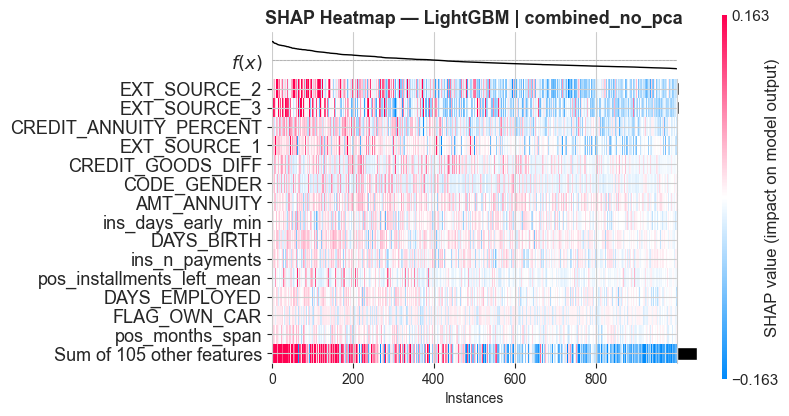

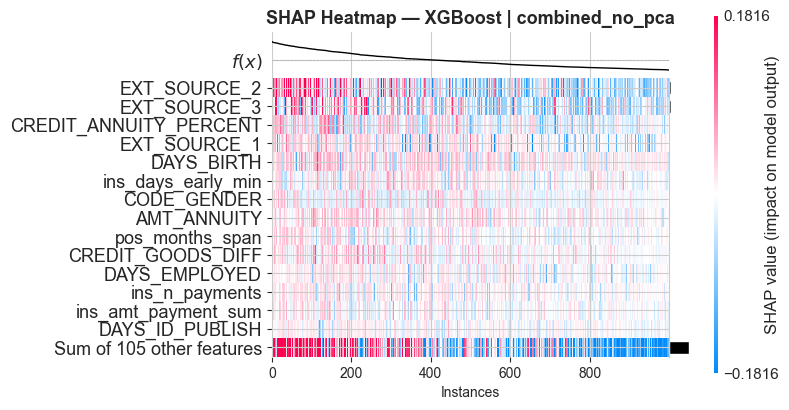

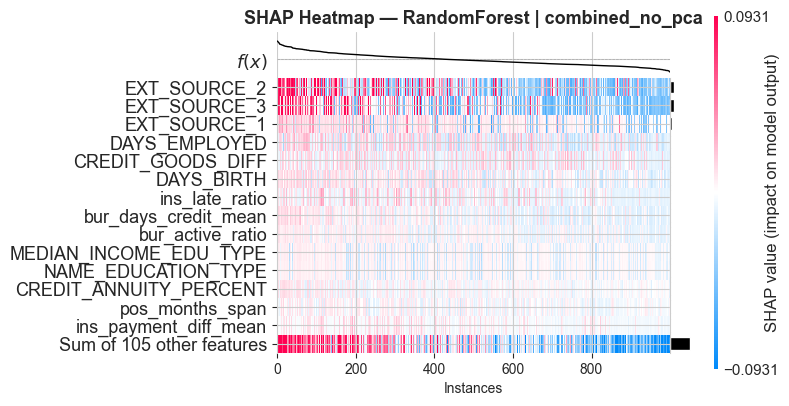

In [34]:
for model_name, sv in all_shap_values.items():
    plt.figure(figsize=(10, 8))
    shap.plots.heatmap(sv, max_display=15, show=False, instance_order=sv.sum(1))
    plt.title(f'SHAP Heatmap — {model_name} | {shap_dataset}', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()

### 7.7 SHAP Feature Importance Tables — All Models

In [35]:
for model_name, sv in all_shap_values.items():
    imp_df = pd.DataFrame({
        'Feature':       X_exp.columns,
        'Mean_SHAP':     np.abs(sv.values).mean(axis=0),
        'Mean_SHAP_pos': sv.values.clip(min=0).mean(axis=0),
        'Mean_SHAP_neg': sv.values.clip(max=0).mean(axis=0),
        'Std_SHAP':      np.abs(sv.values).std(axis=0),
    }).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)

    imp_df[['Mean_SHAP', 'Mean_SHAP_pos', 'Mean_SHAP_neg', 'Std_SHAP']] =         imp_df[['Mean_SHAP', 'Mean_SHAP_pos', 'Mean_SHAP_neg', 'Std_SHAP']].round(6)

    print(f'=== SHAP Feature Importance — {model_name} | {shap_dataset} ===')
    display(
        imp_df.head(30).style
        .background_gradient(subset=['Mean_SHAP'],     cmap='YlOrRd')
        .background_gradient(subset=['Mean_SHAP_pos'], cmap='Greens')
        .background_gradient(subset=['Mean_SHAP_neg'], cmap='Reds_r')
        .format({'Mean_SHAP': '{:.6f}', 'Mean_SHAP_pos': '{:.6f}',
                 'Mean_SHAP_neg': '{:.6f}', 'Std_SHAP': '{:.6f}'})
    )

=== SHAP Feature Importance — LogisticRegression | combined_no_pca ===


,Feature,Mean_SHAP,Mean_SHAP_pos,Mean_SHAP_neg,Std_SHAP
0,EXT_SOURCE_3,0.315109,0.120627,-0.194481,0.235843
1,EXT_SOURCE_2,0.311827,0.145700,-0.166127,0.214048
2,CODE_GENDER,0.177201,0.082924,-0.094276,0.051577
3,AMT_CREDIT,0.176782,0.058817,-0.117965,0.165404
4,pos_months_span,0.159775,0.078145,-0.081630,0.089425
5,prev_n_apps,0.145236,0.082661,-0.062575,0.123662
6,CREDIT_GOODS_DIFF,0.139190,0.091194,-0.047995,0.132182
7,bur_n_active,0.130865,0.075632,-0.055233,0.138728
8,ins_late_ratio,0.127824,0.065451,-0.062373,0.122484
9,pos_installments_left_mean,0.126980,0.062859,-0.064121,0.122020


=== SHAP Feature Importance — LightGBM | combined_no_pca ===


,Feature,Mean_SHAP,Mean_SHAP_pos,Mean_SHAP_neg,Std_SHAP
0,EXT_SOURCE_2,0.055503,0.025251,-0.030252,0.047832
1,EXT_SOURCE_3,0.048525,0.017758,-0.030767,0.043707
2,CREDIT_ANNUITY_PERCENT,0.031797,0.015012,-0.016785,0.023849
3,EXT_SOURCE_1,0.025728,0.012543,-0.013185,0.031070
4,CREDIT_GOODS_DIFF,0.021663,0.013657,-0.008006,0.016536
5,CODE_GENDER,0.021554,0.010365,-0.011189,0.012610
6,AMT_ANNUITY,0.019761,0.013932,-0.005829,0.015060
7,ins_days_early_min,0.019238,0.010023,-0.009215,0.016740
8,DAYS_BIRTH,0.019136,0.012189,-0.006947,0.016613
9,ins_n_payments,0.018619,0.010489,-0.008130,0.014695


=== SHAP Feature Importance — XGBoost | combined_no_pca ===


,Feature,Mean_SHAP,Mean_SHAP_pos,Mean_SHAP_neg,Std_SHAP
0,EXT_SOURCE_2,0.060710,0.027248,-0.033462,0.050254
1,EXT_SOURCE_3,0.055236,0.020292,-0.034943,0.048207
2,CREDIT_ANNUITY_PERCENT,0.039270,0.018023,-0.021247,0.027947
3,EXT_SOURCE_1,0.032189,0.016139,-0.016050,0.034359
4,DAYS_BIRTH,0.031376,0.020373,-0.011003,0.021865
5,ins_days_early_min,0.024329,0.012994,-0.011335,0.021195
6,CODE_GENDER,0.023927,0.011499,-0.012428,0.014494
7,AMT_ANNUITY,0.022578,0.015421,-0.007157,0.017375
8,pos_months_span,0.021911,0.011446,-0.010465,0.017795
9,CREDIT_GOODS_DIFF,0.021079,0.013144,-0.007935,0.017388


=== SHAP Feature Importance — RandomForest | combined_no_pca ===


,Feature,Mean_SHAP,Mean_SHAP_pos,Mean_SHAP_neg,Std_SHAP
0,EXT_SOURCE_2,0.043537,0.020175,-0.023362,0.026067
1,EXT_SOURCE_3,0.035094,0.013365,-0.021729,0.027254
2,EXT_SOURCE_1,0.016227,0.008276,-0.007951,0.015537
3,DAYS_EMPLOYED,0.015335,0.007650,-0.007686,0.006411
4,CREDIT_GOODS_DIFF,0.012066,0.007467,-0.004599,0.005659
5,DAYS_BIRTH,0.010750,0.006131,-0.004619,0.005991
6,ins_late_ratio,0.010668,0.005565,-0.005104,0.006117
7,bur_days_credit_mean,0.009463,0.004569,-0.004894,0.004532
8,bur_active_ratio,0.007951,0.003669,-0.004282,0.003149
9,MEDIAN_INCOME_EDU_TYPE,0.007537,0.003455,-0.004082,0.005598
